# Libraries

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
# Add benchmarking dir so helpers.plot is importable
_bench = Path.cwd().parents[3]
sys.path.insert(0, str(_bench))
from helpers.plot import (
    plot_grouped_bar_by_columns,
    plot_single_bar_metric,
    plot_rank_comparison,
    plot_multi_rank_comparison,
    render_dlq_analysis,
)


# Evaluating SageBench

This notebook summarizes raw query-level metrics from a **Sagebench** benchmark run. The labeled pairs and queries come from **[SageBench](https://huggingface.co/datasets/sagecontinuum/SageBench)** on Hugging Face (**2.4k rows** per the Hub). Retrieval used a [CLIP](https://huggingface.co/apple/DFN5B-CLIP-ViT-H-14-378) checkpoint **`DFN5B-CLIP-ViT-H-14-378`** (DFN-trained), [NRP](https://nrp.ai/documentation/userdocs/ai/llm-managed/#available-models) **[gemma-4-31B-it](https://huggingface.co/google/gemma-4-31B-it)** for captions, and **response_limit=25** (up to 25 images per query), aligned with production.

To better understand the results, each image is matched with a query in the dataset. Although not all matched images are relevant to the query.

This version tested the image search with `DFN5B-CLIP-ViT-H-14-378` and `NRP's gemma-4-31B-it` on **Milvus** (replacing Weaviate), using dual dense indexes plus BM25 and CLIP rerank. It included:

- **gemma-4-31B-it for Caption Generation**: Captions are generated for images using NRP's gemma-4-31B-it model.
- **Dual-index Vector Search**: Image and caption CLIP embeddings are stored as separate Milvus fields (`image_vector`, `caption_vector`) instead of a single fused vector. At query time, dense similarity blends both legs with `clip_alpha` (default 0.7 → 70% image / 30% caption).
- **Keyword Search (BM25)**: Milvus BM25 over `search_text` (captions and related text), replacing Weaviate keyword search.
- **Hybrid Search**: Dense (dual CLIP) + sparse (BM25) retrieval via Milvus `WeightedRanker`, controlled by `query_alpha` (default 0.4 → 40% dense / 60% keyword). Query method: `clip_hybrid_query_dual_index`.
- **CLIP Reranker (`DFN5B-CLIP-ViT-H-14-378`)**: Replaces the previous Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. The query text is embedded once and scored against stored `image_vector`s (no per-hit image I/O), matching production `logits_per_image`-style ranking.
- **Triton Dynamic Batching**: CLIP (and Gemma when served on Triton) use server-side dynamic batching so concurrent embedding/caption requests are coalesced into larger GPU batches, improving indexing and query throughput versus one-request-per-inference.
- **LLM Image Byte Limiting**: Caption images are preprocessed with `LLM_IMAGE_BYTE_LIMITING=true` before NRP gemma calls: RGB conversion, longest-side cap (`LLM_MAX_IMAGE_SIDE=6144`), and JPEG downscale/quality stepping to stay under `LLM_MAX_IMAGE_BYTES` (12 MiB).
- **Two-caption prompt (`scientific_two_captions_v1`)**: Caption generation uses the shared [`prompts/`](../../../../../prompts/) catalog (`CAPTION_PROMPT_ID=scientific_two_captions_v1`). Gemma returns three fields: `long_caption` (full detail), `short_caption` (one dense visual sentence, ≤55 tokens, no device IDs/timestamps), and 15 `keywords`. The older versions used CAPTION_PROMPT_ID=scientific_detailed_v1 which utilized only long_caption.
- **CLIP text vs BM25 text split**: CLIP's 77-token limit previously truncated the full caption+keywords string (~40% embedded; keywords never reached `caption_vector`). v15 embeds **`short_caption` + `keywords`** for `caption_vector` in a single CLIP pass, while BM25 `search_text` still indexes **`long_caption` + keywords** (no detail lost on the keyword leg).
- **Milvus caption fields**: `long_caption` and `short_caption` are stored as separate VARCHAR fields (replacing a single `caption` column).

Here were the Hyperparameters used for the image search:

In [2]:
#show config values
df = pd.read_csv('config_values.csv')
df

,Config Variable,Value,Type
0,DATASET_DEFAULT,sagecontinuum/SageBench,str
1,advanced_query_parameters,"{'query_alpha': 0.4, 'clip_alpha': 0.7, 'enabl...",dict
2,caption_model_name,gemma,str
3,caption_model_prompt,role:\nYou are a world-class Scientific Image ...,str
4,embed_caption,True,bool
5,embed_image,True,bool
6,enable_bm25,True,bool
7,enable_caption_generation,True,bool
8,hnsw_dist_metric,VectorDistances.COSINE,VectorDistances
9,hnsw_dynamicEfMax,500,int


## Query and image collection process

The following follows the **[SageBench dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench)** so metrics below are easier to interpret.

### Query collection

Queries in SageBench are **natural-language descriptions** of **Sage Continuum** sensor imagery, aimed at how researchers would search when **both visuals and node metadata** matter. They are **model-generated** (e.g. OpenAI **GPT-5-mini** in the published pipeline).

**Process (see [SageBench](https://huggingface.co/datasets/sagecontinuum/SageBench)):**

1. **Seed images** — `query_plan_num_seeds` controls how many seeds are drawn from the candidate pool.
2. **Query generation** — For each seed, the model produces a query that a user might type to find that scene; prompts require **at least one** reference to Sage fields (**vsn**, **zone**, **host**, **job**, **plugin**, **camera**, **project**, **address**) plus visual content (example style: *“Animal … from vsn V001, job imagesampler-bottom-1 (core zone)”*).
3. **One query per seed** — Each query gets a **`query_id`** (e.g. `query_001`) and drives candidate retrieval and labeling.

Full pipeline options and costs are documented on the Hub and in **`config_values.csv`** (and `summary/` in the dataset repo).


### Image annotation

SageBench combines **per-image vision outputs**, **per-pair relevance labels**, and an offline **CLIP** score—see the [dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench).

**1. Vision annotation (per image)** — OpenAI vision (**GPT-5-mini**) in the published pipeline:

- **summary** — Short factual caption (≤30 words).
- **Taxonomy** — `viewpoint`, `lighting`, `environment_type`, `sky_condition` (allowed values are fixed in the benchmaker config).
- **Boolean scene flags** — `horizon_present`, `ground_present`, `sky_dominates`, `vegetation_present`, `water_present`, `buildings_present`, `vehicle_present`, `person_present`, `animal_present`, `night_scene`, `precipitation_visible`, `multiple_objects`.
- **tags** — Controlled vocabulary (roughly 12–18 tags per image).
- **confidence** — Dict of scores (e.g. for taxonomy dimensions) in `[0, 1]`.

**Sage metadata** (per image, for retrieval and analysis): **vsn**, **zone**, **host**, **job**, **plugin**, **camera**, **project**, **address** — `project` and `address` are resolved via the Sage manifest API in the dataset build ([card](https://huggingface.co/datasets/sagecontinuum/SageBench)).

**2. Relevance labeling (per query–image pair)** — An **AI judge** (GPT-5-mini) assigns **relevance_label** ∈ {0, 1}, following **metadata-aware** criteria: both whether the **query’s metadata constraints** match the candidate image and whether the **visual content** fits.

**3. CLIPScore** — Precomputed text–image similarity as **clip_score** using **`apple/DFN5B-CLIP-ViT-H-14-378`** (same family as this benchmark’s CLIP backbone).

Hyperparameter tables: **`summary/config_values.csv`** in this results folder and on the Hub.


### Query Categories

SageBench does **not** use a single categorical “topic” per query. Instead, each row carries **Sage metadata**, **scene taxonomy**, and **tags**, so you can slice metrics by node, camera, environment, etc. (aligned with the [Hub schema](https://huggingface.co/datasets/sagecontinuum/SageBench)).

**Sage metadata (strings)** — `vsn`, `zone`, `host`, `job`, `plugin`, `camera`, `project`, `address`

**Scene taxonomy (strings)** — `viewpoint` (e.g. `ground_horizontal`, `fisheye_sky`, `duo_view`), `lighting` (e.g. `day`, `night`, `dusk`, `overcast_light`), `environment_type` (e.g. `vegetation`, `sky_dominant`, `ground_dominant`, `mixed`, `urban`, `rural`), `sky_condition` (e.g. `clear`, `partly_cloudy`, `overcast`, `fog_or_haze`)

**Boolean scene flags** — Same list as in vision annotation (`horizon_present` … `multiple_objects`).

Queries are written so retrieval must handle **metadata-in-the-text** (node id, job name, zone, camera, address snippets, …) **and** visual cues—see the dataset card for curation rationale and limitations (e.g. binary relevance, generator coverage).


### Data Split
The dataset only has a train split. Users can split the dataset as they see fit.

## Query Coverage

Queries cover a range of topics and taxonomies:

![Image Sample](https://huggingface.co/datasets/sagecontinuum/SageBench/resolve/main/summary/random_image_sample.png)
![Query Coverage](https://huggingface.co/datasets/sagecontinuum/SageBench/resolve/main/summary/image_proportion_donuts.png)


## Exploratory data analysis

The SageBench repo on the Hub includes a notebook with charts and tables over the published split.

**[SageBench EDA (Hub)](https://huggingface.co/datasets/sagecontinuum/SageBench/blob/main/summary/SageBench_eda_analysis.ipynb)**

Use it alongside the metrics below to relate aggregate scores to metadata and taxonomy distributions.

## Query metric dataset

Each row summarizes **one query** from **[SageBench](https://huggingface.co/datasets/sagecontinuum/SageBench)** (`query_text` / `query_id` on the Hub) and how the search system performed on it.

### Columns in `query_eval_metrics.csv` (one row per query)

- **query_id**: Matches **`query_id`** in SageBench (e.g. `query_001`).
- **query** (source column **`query_text`**): Text sent to retrieval; must be metadata-aware per the [dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench).
- **total_images**: Total images returned for that query (up to **response_limit**).
- **correctly_returned**: Count of returned images whose paired query in the dataset matches the query used in search.
- **incorrectly_returned**: Count of returned images whose paired query in the dataset does not match the query used in search.
- **relevant_images**: Count of returned images labeled relevant to the query in the dataset.
- **non_relevant_images**: Count of returned images labeled non-relevant to the query in the dataset.
- **accuracy**: Share of returned images that are “correctly returned” vs **total_images**.
- **precision**: Share of returned images that are relevant vs **total_images**.
- **recall**: Share of relevant items in the dataset that appear in the returned top-k (see benchmark code for the exact denominator).
- **hit**: `1` if at least one relevant image appears in the top-k; mean over queries = hit rate @ k (**k** = **response_limit**).
- **NDCG** (from `rerank_score_NDCG`): Ranking quality using the **reranker** scores; higher means relevant items rank higher.
- **clip_NDCG** (from `clip_score_NDCG`): Same as NDCG but using **CLIP** scores from the dataset for comparison.
- **rr** (from `rerank_score_reciprocal_rank`): Reciprocal rank of the first relevant item using reranker scores; mean = MRR.
- **clip_rr** (from `clip_score_reciprocal_rank`): Reciprocal rank using CLIP scores for comparison.
- **diversity**: Diversity of the top-k list (1 − intra-list similarity of retrieved vectors); higher = less redundant results.
- **vsn (Sage metadata)**: The vsn (node identifier) that took the original image the query was generated from.
- **zone (Sage metadata)**: The zone (compute zone in the node) that took the original image the query was generated from.
- **host (Sage metadata)**: The host (compute host in the node) that took the original image the query was generated from.
- **job (Sage metadata)**: The job (job identifier) that took the original image the query was generated from.
- **plugin (Sage metadata)**: The plugin (plugin identifier) that took the original image the query was generated from.
- **camera (Sage metadata)**: The camera (camera identifier) that took the original image the query was generated from.
- **project (Sage metadata)**: The project (project identifier) that took the original image the query was generated from.
- **address (Sage metadata)**: The address (the node address location) that took the original image the query was generated from.
- **viewpoint**: The viewpoint of the original image the query was generated from.
- **lighting**: The lighting of the original image the query was generated from.
- **environment_type**: The environment type of the original image the query was generated from.
- **sky_condition**: The sky condition of the original image the query was generated from.
- **horizon_present**: Whether the horizon is present in the seed image associated with the query.
- **ground_present**: Whether the ground is present in that seed image.
- **sky_dominates**: Whether the sky dominates the frame (**`sky_dominates`** on the Hub).
- **vegetation_present**: Whether vegetation is present in that seed image.
- **water_present**: Whether water is present in the original image the query was generated from.
- **buildings_present**: Whether buildings are present in the original image the query was generated from.
- **vehicle_present**: Whether a vehicle is present in the original image the query was generated from.
- **person_present**: Whether a person is present in the original image the query was generated from.
- **animal_present**: Whether an animal is present in the original image the query was generated from.
- **night_scene**: Whether it is night time in the original image the query was generated from.
- **precipitation_visible**: Whether precipitation is visible in the original image the query was generated from.
- **multiple_objects**: Whether multiple salient objects appear in the original image the query was generated from.


In [3]:
#load in metric data
df = pd.read_csv('query_eval_metrics.csv')

#rename ndcg and reciprocal rank columns
df = df.rename(columns={
    'rerank_score_NDCG': 'NDCG',
    'clip_score_NDCG': 'clip_NDCG',
    'rerank_score_reciprocal_rank': 'rr',
    'clip_score_reciprocal_rank': 'clip_rr'
})
df

,query_id,query,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,...,sky_dominates,vegetation_present,water_present,buildings_present,vehicle_present,person_present,animal_present,night_scene,precipitation_visible,multiple_objects
0,query_004,pond with dock and small house from vsn W083 (...,25,1,24,1,24,0.04,0.04,1.0,...,False,True,True,True,False,False,False,False,False,True
1,query_002,Indoor tiled floor with yellow caution tape an...,25,1,24,1,24,0.04,0.04,1.0,...,False,False,False,True,False,False,False,False,False,True
2,query_008,sunny grassy field with dirt road and bright s...,25,0,25,0,25,0.00,0.00,0.0,...,True,True,False,False,False,False,False,False,False,True
3,query_001,Wet paved industrial yard with puddles and an ...,25,1,24,1,24,0.04,0.04,1.0,...,False,False,True,True,True,False,False,False,False,True
4,query_006,night view of a paved/parking area with grassy...,25,1,24,1,24,0.04,0.04,1.0,...,False,True,False,True,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,query_115,sunlit fisheye sky view showing trailer and ta...,25,2,23,2,23,0.08,0.08,1.0,...,True,True,False,True,True,False,False,False,False,True
116,query_119,Snow-covered valley with cabins and fences in ...,25,1,24,1,24,0.04,0.04,1.0,...,True,True,False,True,False,False,False,False,True,True
117,query_120,daytime parking lot with parked cars from vsn ...,25,1,24,1,24,0.04,0.04,1.0,...,False,True,False,True,True,False,False,False,False,True
118,query_117,overcast rainy fisheye sky with raindrops on l...,25,1,24,1,24,0.04,0.04,1.0,...,True,True,False,False,False,False,False,False,True,True


## Indexing DLQ Summary

First, we will look at the DLQ to get an understanding of failed items.

During indexing, failed items are held in a dead-letter queue (`dlq_records.csv`), retried with exponential backoff, then recorded with a terminal status.

CSV columns: `image_id`, `query_id`, `reason`, `error`, `attempts`, `final_status`, `last_error`.

| `final_status` | Meaning |
|----------------|---------|
| `retried_ok` | A later retry succeeded with a real LLM caption |
| `inserted_degraded` | Soft caption failure exhausted retries; item was **force-inserted** using the dataset `summary` as caption backup (or `""` if none) |
| `abandoned` | Hard failure (or force-insert failed); item was **not** indexed |

`reason` is typically `caption_failed` (empty LLM caption) or `hard_fail` (CLIP / processing errors). Use the tables below to see how often fallback was used versus full abandon.

In [4]:
render_dlq_analysis(Path("."))


DLQ rows: 0  |  unique image_ids: 0 | unique query_ids: 0
Nothing to summarize.


## Overall Metrics
Now, we will begin with evaluating all queries.

In [5]:
#calculate the average/sum of each metric
total_images = df['total_images'].sum()
correctly_returned = df['correctly_returned'].sum()
incorrectly_returned = df['incorrectly_returned'].sum()
relevant_images = df['relevant_images'].sum()
non_relevant_images = df['non_relevant_images'].sum()
accuracy = df['accuracy'].mean()
precision = df['precision'].mean()
recall = df['recall'].mean()
hit_rate = df['hit'].mean()
ndcg = df['NDCG'].mean()
clip_ndcg = df['clip_NDCG'].mean()
mrr = df['rr'].mean()
clip_mrr = df['clip_rr'].mean()
diversity = df['diversity'].mean()

# Summary of key metrics
overall_metrics = {
    'total_images': total_images,
    'correctly_returned': correctly_returned,
    'incorrectly_returned': incorrectly_returned,
    'relevant_images': relevant_images,
    'non_relevant_images': non_relevant_images,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'hit_rate': hit_rate,
    'NDCG': ndcg,
    'clip_NDCG': clip_ndcg,
    'mrr': mrr,
    'clip_mrr': clip_mrr,
    'diversity': diversity
}

# Print the summary
for key, value in overall_metrics.items():
    print(f"{key}: {value}")

# Insights
print("\nInsights:")
print(f"The system returned a total of {correctly_returned} correct images out of {total_images} total images returned.")
print(f"The accuracy of the system is {accuracy:.4f}, indicating that {accuracy*100:.2f}% of the returned images correctly matched with the query.")
print(f"The precision of the system is {precision:.4f}, indicating that {precision*100:.2f}% of the total images returned were relevant images.")
print(f"The recall of the system is {recall:.4f}, indicating that {recall*100:.2f}% of the total relevant images in the dataset were returned.")
print(f"The hit rate of the system is {hit_rate:.4f}, indicating that {hit_rate*100:.2f}% of the total queries processed had at least one relevant image.")
print(f"The NDCG score is {ndcg:.4f}, and the Clip NDCG score is {clip_ndcg:.4f}, indicating the ranking quality of the returned images against the CLIP DFN5B-CLIP-ViT-H-14-378 model.")
print(f"The MRR score is {mrr:.4f}, and the Clip MRR score is {clip_mrr:.4f}, indicating how early the first relevant result appears.")
print(f"The diversity of the system is {diversity:.4f} (on a 0–1 scale), indicating the \"spread\" of the returned images. A lower score means the results are more redundant (i.e., highly similar to each other), while a higher score indicates more varied results.")

total_images: 3000
correctly_returned: 91
incorrectly_returned: 2909
relevant_images: 81
non_relevant_images: 2919
accuracy: 0.03033333333333333
precision: 0.026999999999999993
recall: 0.5919444444444444
hit_rate: 0.6416666666666667
NDCG: 0.32193572164143175
clip_NDCG: 0.4868936346817953
mrr: 0.22965652281441754
clip_mrr: 0.43855158730158733
diversity: 0.226040348112768

Insights:
The system returned a total of 91 correct images out of 3000 total images returned.
The accuracy of the system is 0.0303, indicating that 3.03% of the returned images correctly matched with the query.
The precision of the system is 0.0270, indicating that 2.70% of the total images returned were relevant images.
The recall of the system is 0.5919, indicating that 59.19% of the total relevant images in the dataset were returned.
The hit rate of the system is 0.6417, indicating that 64.17% of the total queries processed had at least one relevant image.
The NDCG score is 0.3219, and the Clip NDCG score is 0.4869,

## Metrics based on Environment Type

Now, we will evaluate queries based on their environment type.


In [6]:
# Group by environment type and calculate the sum/mean of each metric
environment_metrics = df.groupby('environment_type').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
environment_metrics = environment_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

environment_metrics

,environment_type,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,ground_dominant,300,7,293,7,293,0.023333,0.023333,0.541667,0.583333,0.309937,0.429059,0.241595,0.377778,0.199792
1,mixed,800,24,776,23,777,0.030000,0.028750,0.631250,0.687500,0.396712,0.525304,0.293599,0.475000,0.223011
2,other,100,5,95,4,96,0.050000,0.040000,1.000000,1.000000,0.369719,0.815465,0.199653,0.750000,0.246549
3,rural,75,4,71,3,72,0.053333,0.040000,1.000000,1.000000,0.566972,1.000000,0.444444,1.000000,0.284715
4,sky_dominant,875,33,842,28,847,0.037714,0.032000,0.661905,0.742857,0.348666,0.561784,0.234306,0.502336,0.198619
5,unknown,75,3,72,3,72,0.040000,0.040000,0.555556,0.666667,0.341751,0.625738,0.361111,0.666667,0.370454
6,urban,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,0.356207,0.386853,0.166667,0.200000,0.377062
7,vegetation,750,14,736,12,738,0.018667,0.016000,0.383333,0.400000,0.181789,0.276015,0.122727,0.237037,0.243686


### Accuracy

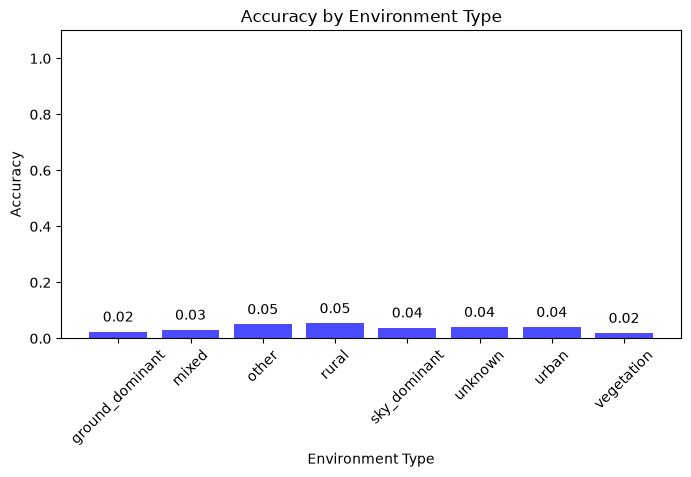

In [7]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='accuracy', title='Accuracy by Environment Type', ylabel='Accuracy', xlabel='Environment Type')

### Precision

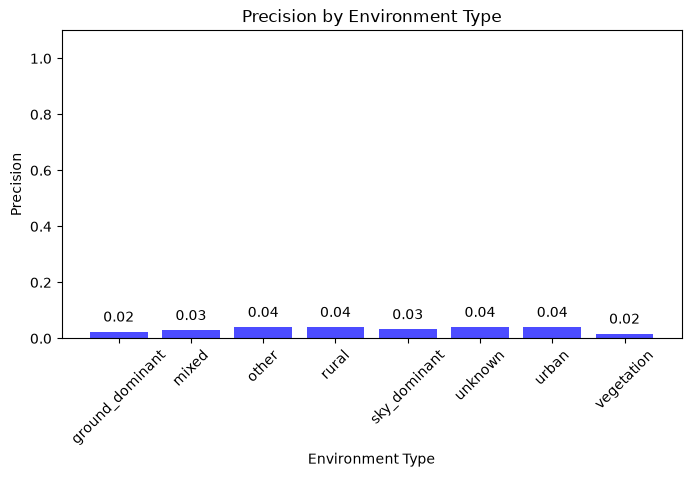

In [8]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='precision', title='Precision by Environment Type', ylabel='Precision', xlabel='Environment Type')

### Recall

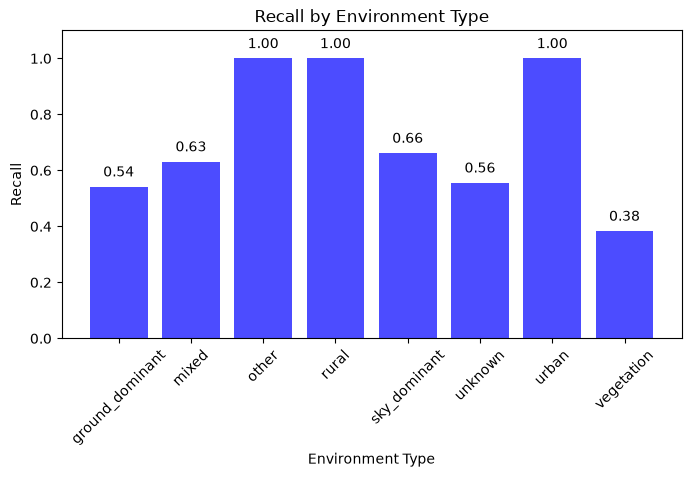

In [9]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='recall', title='Recall by Environment Type', ylabel='Recall', xlabel='Environment Type')

### Hit Rate

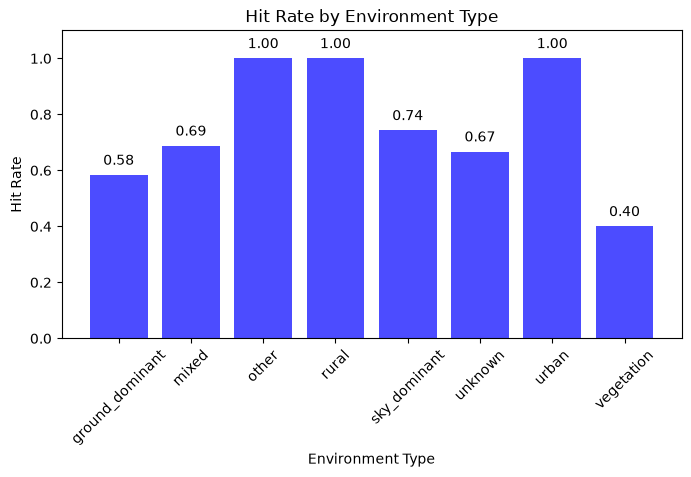

In [10]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='hit_rate', title='Hit Rate by Environment Type', ylabel='Hit Rate', xlabel='Environment Type')

### Diversity


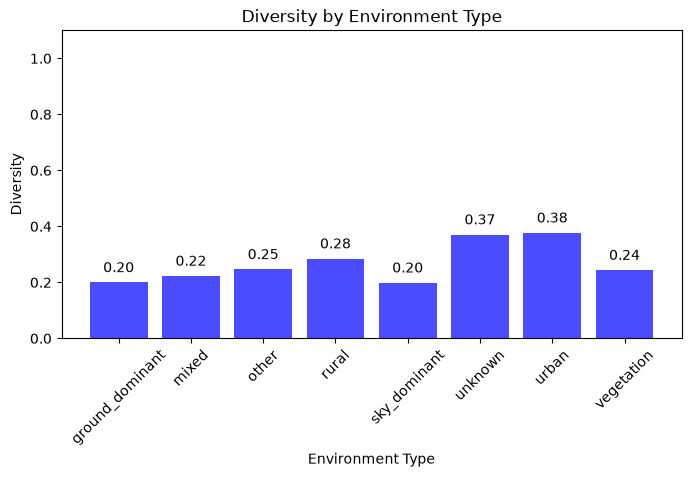

In [11]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='diversity', title='Diversity by Environment Type', ylabel='Diversity', xlabel='Environment Type')

### NDCG

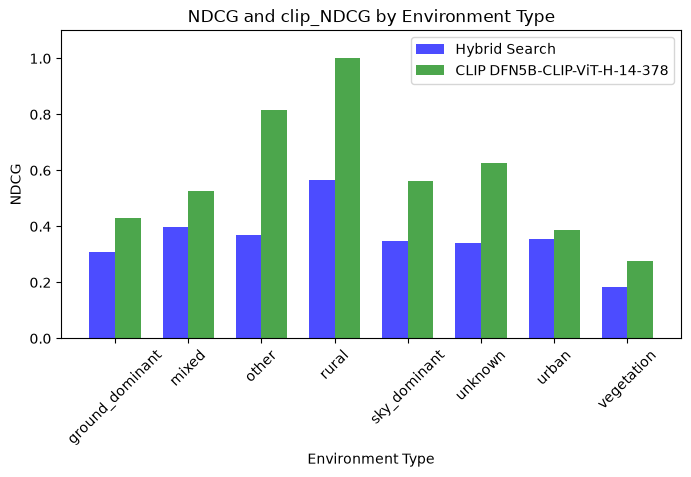

In [12]:
plot_rank_comparison(environment_metrics, x_column='environment_type', title='NDCG and clip_NDCG by Environment Type', xlabel='Environment Type')

### MRR

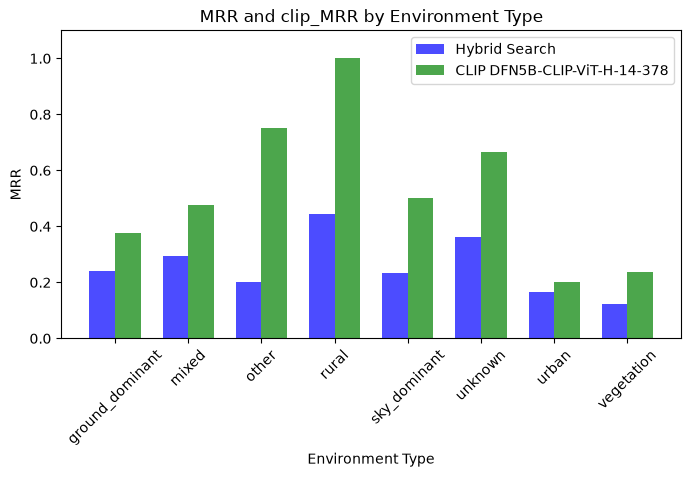

In [13]:
plot_rank_comparison(environment_metrics, x_column='environment_type', title='MRR and clip_MRR by Environment Type', xlabel='Environment Type', metric="MRR")

## Metrics based on Lighting

In [14]:


# Group by iconic_group and calculate the sum/mean of each metric
lighting_metrics = df.groupby(['lighting']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
lighting_metrics = lighting_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

lighting_metrics

,lighting,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,day,1625,50,1575,43,1582,0.030769,0.026462,0.579487,0.630769,0.310253,0.488081,0.210033,0.438718,0.211911
1,dusk,75,3,72,2,73,0.040000,0.026667,0.233333,0.666667,0.666667,0.666667,0.666667,0.666667,0.146516
2,night,1025,29,996,27,998,0.028293,0.026341,0.589431,0.609756,0.282989,0.430567,0.212060,0.382753,0.250296
3,overcast_light,225,7,218,7,218,0.031111,0.031111,0.722222,0.777778,0.451625,0.601979,0.313255,0.546296,0.241907
4,unknown,50,2,48,2,48,0.040000,0.040000,1.000000,1.000000,0.399336,0.815465,0.196429,0.750000,0.235897


In [15]:
# Bar width
bar_width = 0.35
x = np.arange(len(lighting_metrics['lighting']))

### Accuracy

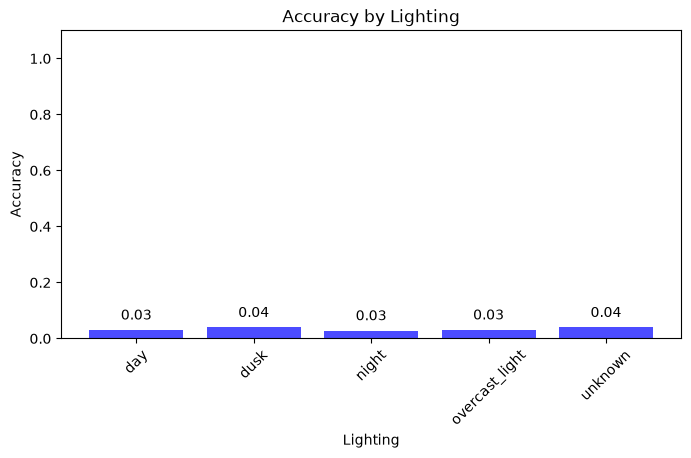

In [16]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='accuracy', title='Accuracy by Lighting', ylabel='Accuracy', xlabel='Lighting')

### Precision

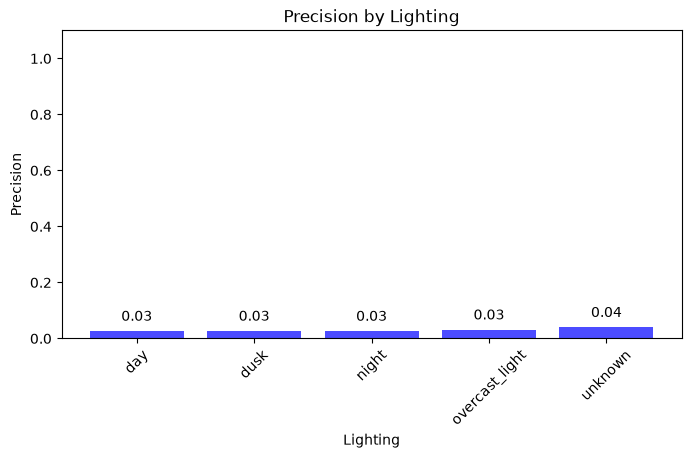

In [17]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='precision', title='Precision by Lighting', ylabel='Precision', xlabel='Lighting')

### Recall

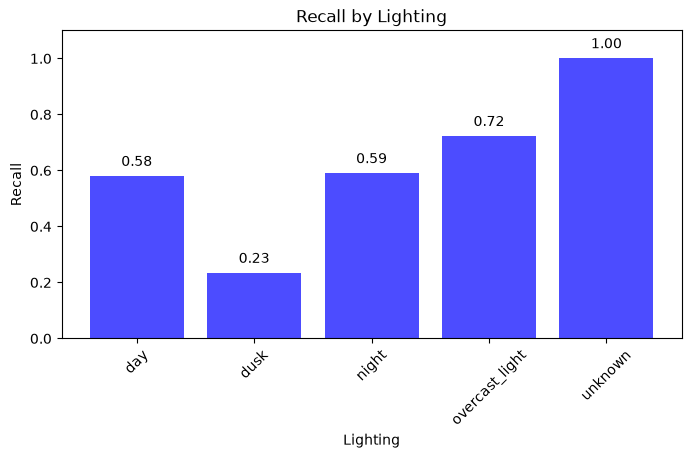

In [18]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='recall', title='Recall by Lighting', ylabel='Recall', xlabel='Lighting')

### Hit Rate

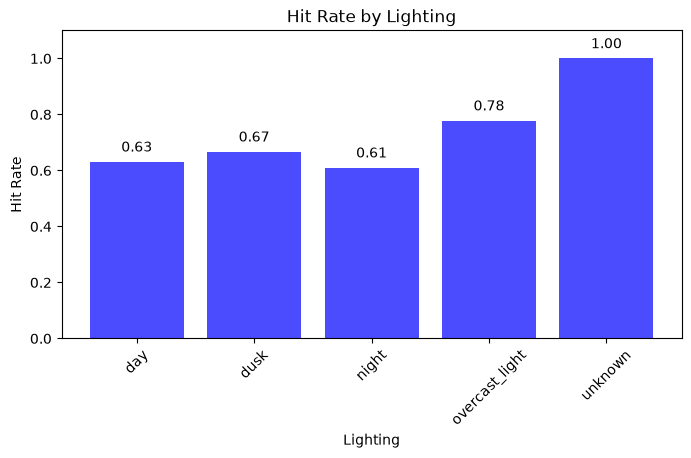

In [19]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='hit_rate', title='Hit Rate by Lighting', ylabel='Hit Rate', xlabel='Lighting')

### Diversity

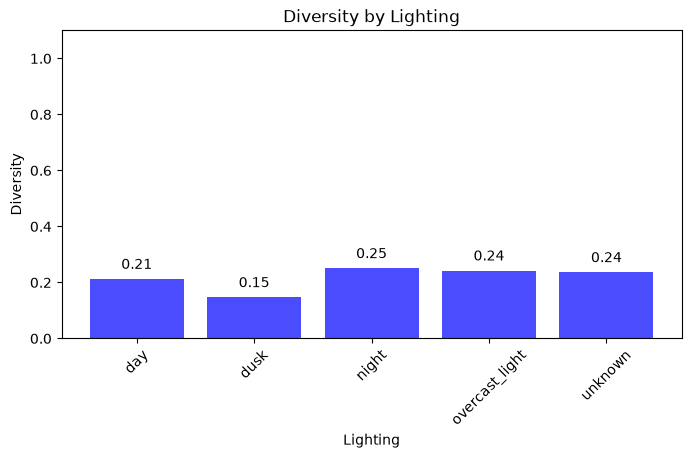

In [20]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='diversity', title='Diversity by Lighting', ylabel='Diversity', xlabel='Lighting')

### NDCG

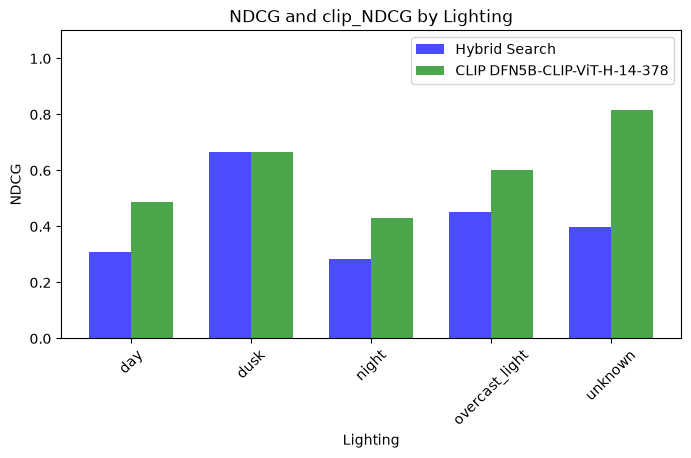

In [21]:
plot_rank_comparison(lighting_metrics, x_column='lighting', title='NDCG and clip_NDCG by Lighting', xlabel='Lighting')

### MRR

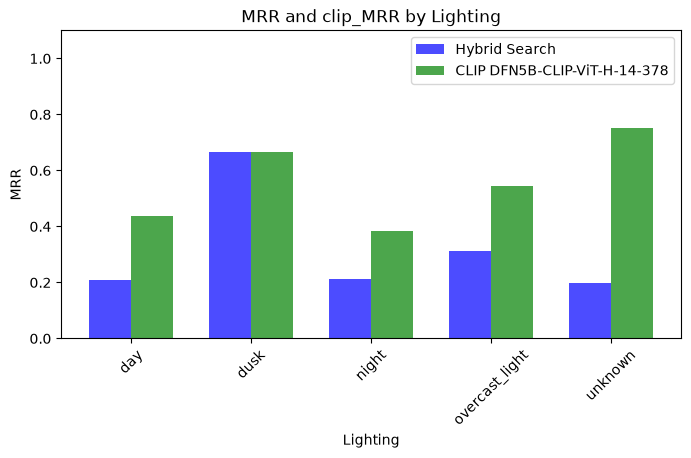

In [22]:
plot_rank_comparison(lighting_metrics, x_column='lighting', title='MRR and clip_MRR by Lighting', xlabel='Lighting', metric="MRR")

## Metrics based on Viewpoint

In [23]:
# Group by viewpoint and calculate the sum/mean of each metric
viewpoint_metrics = df.groupby('viewpoint').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
viewpoint_metrics = viewpoint_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

viewpoint_metrics

,viewpoint,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,duo_view,50,2,48,2,48,0.040000,0.040000,1.000000,1.000000,0.308247,0.750000,0.118056,0.666667,0.188006
1,fisheye_sky,700,28,672,23,677,0.040000,0.032857,0.648810,0.750000,0.352199,0.586040,0.231380,0.529960,0.177244
2,ground_horizontal,1925,51,1874,47,1878,0.026494,0.024416,0.567532,0.597403,0.301070,0.447520,0.212442,0.400701,0.239948
3,ground_upward,150,5,145,5,145,0.033333,0.033333,0.833333,0.833333,0.452806,0.530309,0.358772,0.433333,0.271401
4,oblique,125,3,122,2,123,0.024000,0.016000,0.300000,0.400000,0.300000,0.400000,0.266667,0.400000,0.193174
5,unknown,50,2,48,2,48,0.040000,0.040000,0.333333,0.500000,0.377508,0.438608,0.500000,0.500000,0.357865


### Accuracy

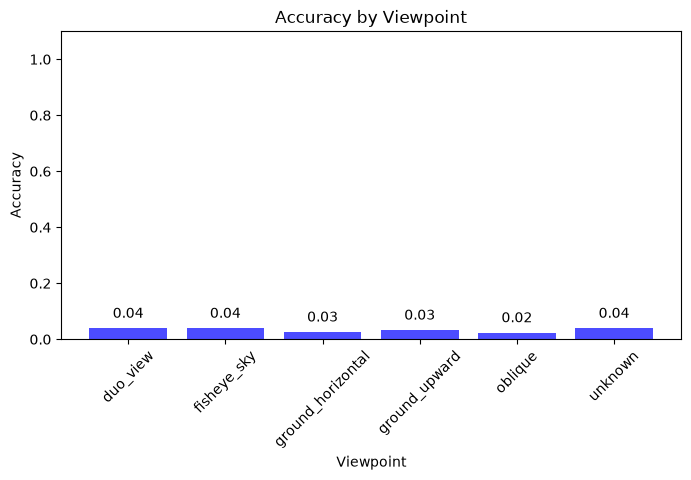

In [24]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='accuracy', title='Accuracy by Viewpoint', ylabel='Accuracy', xlabel='Viewpoint')

### Precision

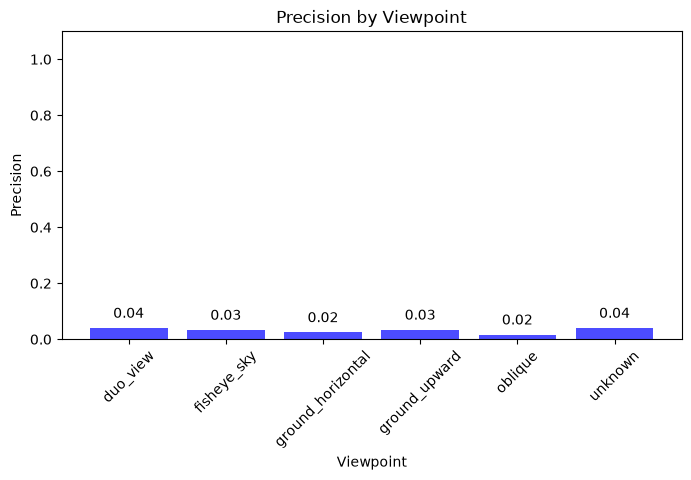

In [25]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='precision', title='Precision by Viewpoint', ylabel='Precision', xlabel='Viewpoint')

### Recall

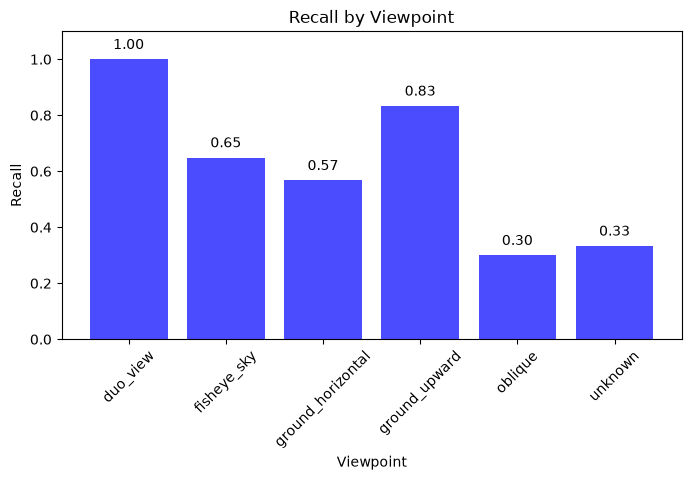

In [26]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='recall', title='Recall by Viewpoint', ylabel='Recall', xlabel='Viewpoint')

### Hit Rate

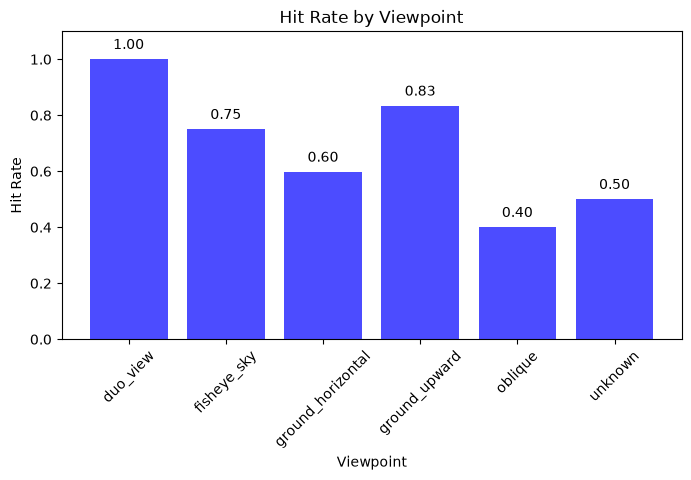

In [27]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='hit_rate', title='Hit Rate by Viewpoint', ylabel='Hit Rate', xlabel='Viewpoint')

### Diversity

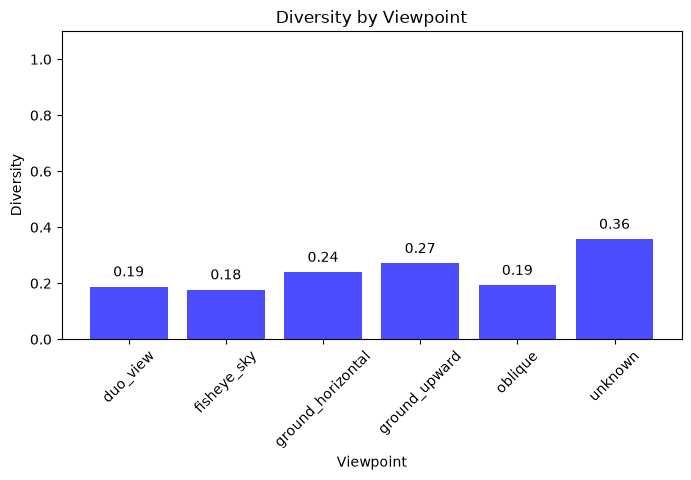

In [28]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='diversity', title='Diversity by Viewpoint', ylabel='Diversity', xlabel='Viewpoint')

### NDCG

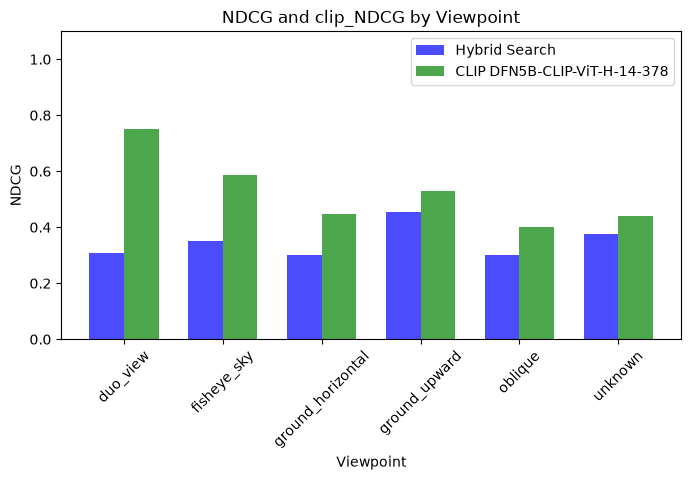

In [29]:
plot_rank_comparison(viewpoint_metrics, x_column='viewpoint', title='NDCG and clip_NDCG by Viewpoint', xlabel='Viewpoint')

### MRR

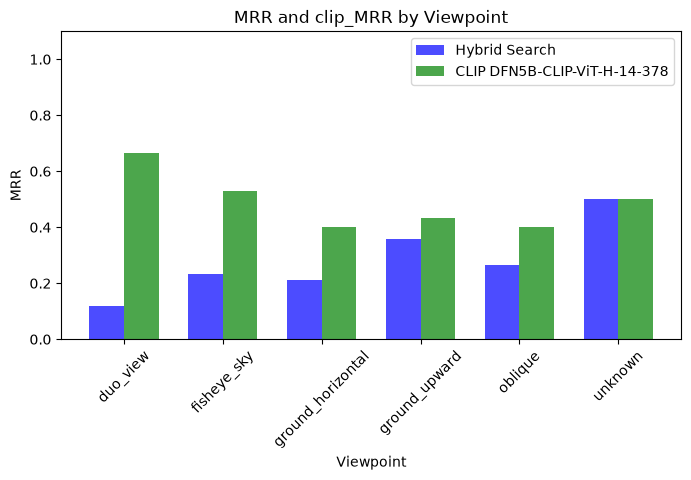

In [30]:
plot_rank_comparison(viewpoint_metrics, x_column='viewpoint', title='MRR and clip_MRR by Viewpoint', xlabel='Viewpoint', metric="MRR")

## Metrics based on Sky Condition

Now, we will evaluate queries based on sky condition.


In [31]:
# Group by sky_condition and calculate the sum/mean of each metric
sky_condition_metrics = df.groupby('sky_condition').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
sky_condition_metrics = sky_condition_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

sky_condition_metrics


,sky_condition,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,clear,1000,28,972,24,976,0.028000,0.024000,0.529167,0.550000,0.278866,0.390518,0.202565,0.338472,0.230880
1,fog_or_haze,225,4,221,4,221,0.017778,0.017778,0.388889,0.444444,0.299599,0.362429,0.236111,0.333333,0.191441
2,other,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,0.630930,0.630930,0.500000,0.500000,0.333230
3,overcast,500,18,482,16,484,0.036000,0.032000,0.750000,0.800000,0.387896,0.624860,0.228180,0.568333,0.242345
4,partly_cloudy,700,22,678,19,681,0.031429,0.027143,0.542857,0.642857,0.364527,0.538370,0.296864,0.505952,0.193172
5,unknown,550,18,532,17,533,0.032727,0.030909,0.689394,0.727273,0.281166,0.515552,0.179791,0.456999,0.253534


### Accuracy


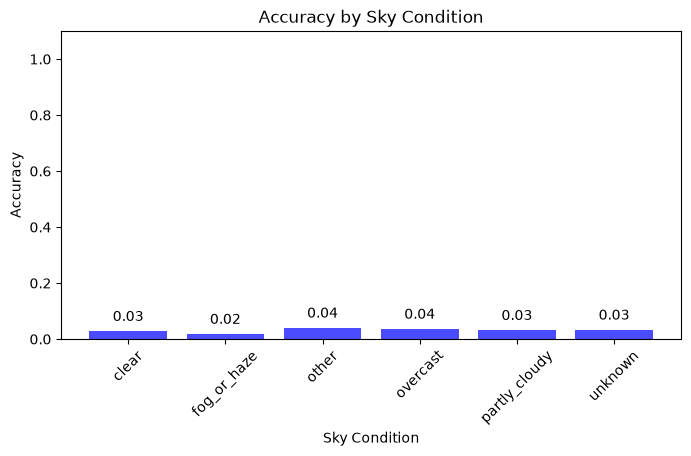

In [32]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='accuracy', title='Accuracy by Sky Condition', ylabel='Accuracy', xlabel='Sky Condition')


### Precision


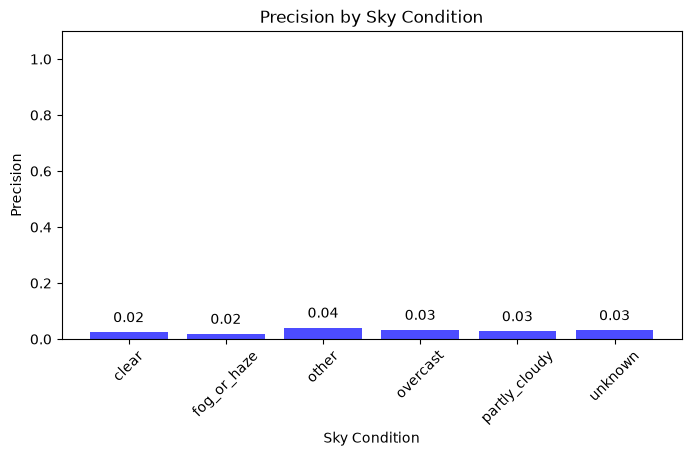

In [33]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='precision', title='Precision by Sky Condition', ylabel='Precision', xlabel='Sky Condition')


### Recall


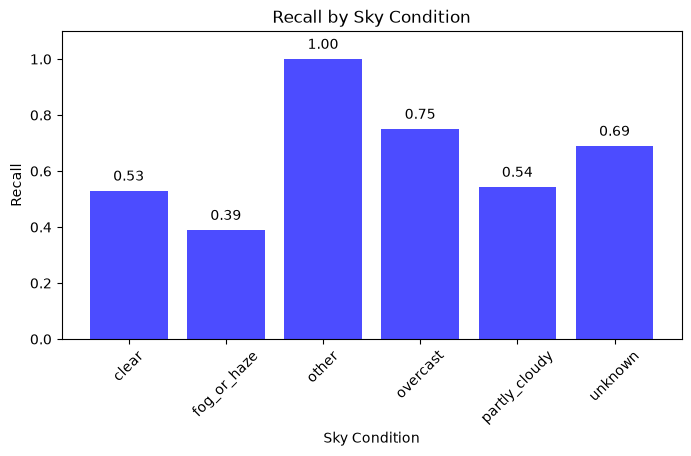

In [34]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='recall', title='Recall by Sky Condition', ylabel='Recall', xlabel='Sky Condition')


### Hit Rate


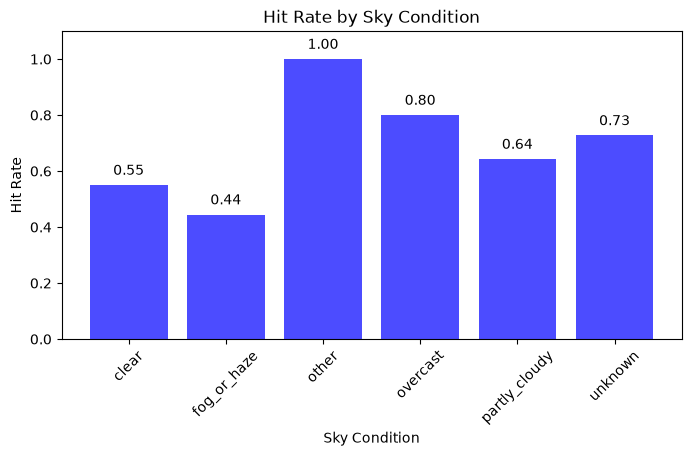

In [35]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='hit_rate', title='Hit Rate by Sky Condition', ylabel='Hit Rate', xlabel='Sky Condition')


### Diversity


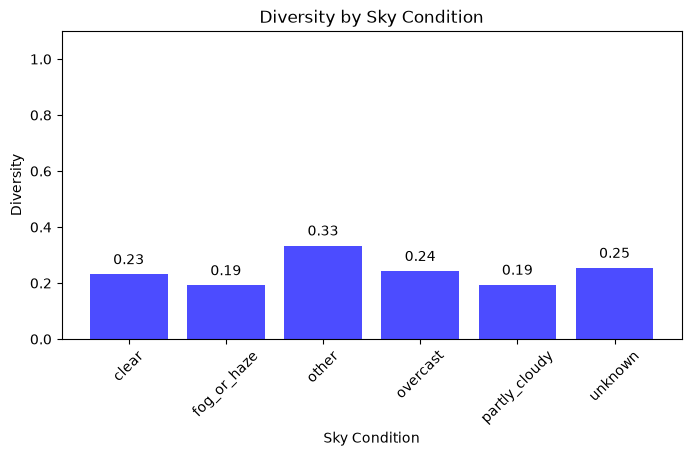

In [36]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='diversity', title='Diversity by Sky Condition', ylabel='Diversity', xlabel='Sky Condition')


### NDCG


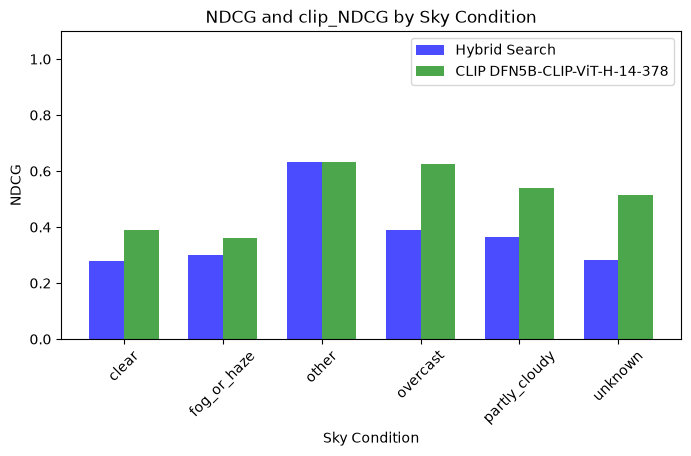

In [37]:
plot_rank_comparison(sky_condition_metrics, x_column='sky_condition', title='NDCG and clip_NDCG by Sky Condition', xlabel='Sky Condition')


### MRR


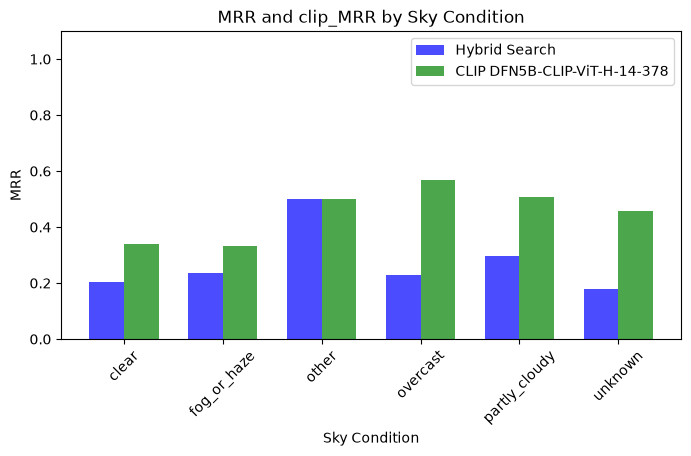

In [38]:
plot_rank_comparison(sky_condition_metrics, x_column='sky_condition', title='MRR and clip_MRR by Sky Condition', xlabel='Sky Condition', metric="MRR")


## Metrics based on Horizon Present

Now, we will evaluate queries based on **Horizon Present** (true vs false).


In [39]:
# Group by horizon_present and calculate the sum/mean of each metric
horizon_present_metrics = df.groupby('horizon_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
horizon_present_metrics['horizon_present'] = horizon_present_metrics['horizon_present'].map({True: 'True', False: 'False'})

#rename columns
horizon_present_metrics = horizon_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
horizon_present_metrics = horizon_present_metrics.sort_values('horizon_present')

horizon_present_metrics


,horizon_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,850,26,824,23,827,0.030588,0.027059,0.607843,0.647059,0.342547,0.510485,0.269068,0.470588,0.249453
1,True,2150,65,2085,58,2092,0.030233,0.026977,0.585659,0.639535,0.313787,0.477567,0.214075,0.425886,0.216784


### Accuracy


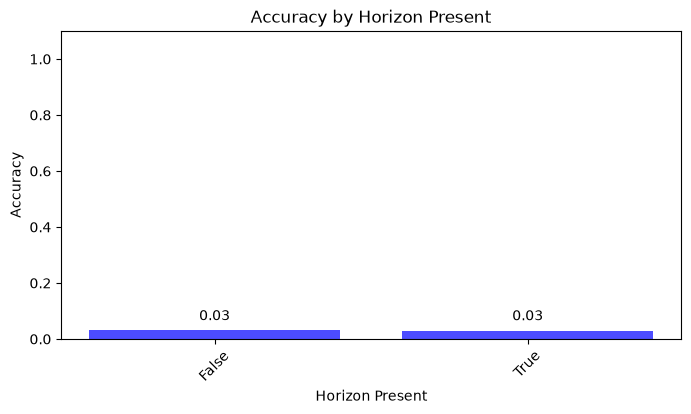

In [40]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='accuracy', title='Accuracy by Horizon Present', ylabel='Accuracy', xlabel='Horizon Present')


### Precision


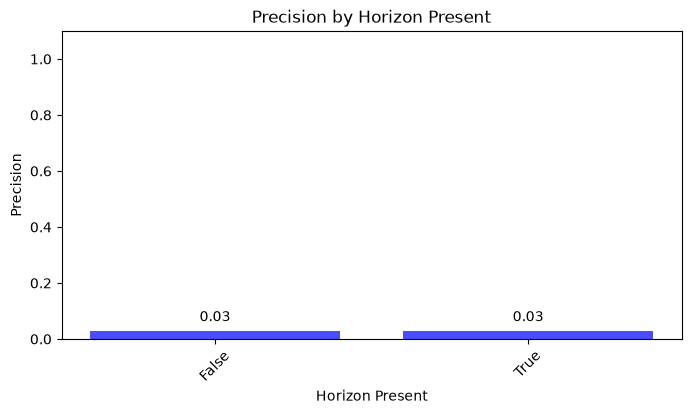

In [41]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='precision', title='Precision by Horizon Present', ylabel='Precision', xlabel='Horizon Present')


### Recall


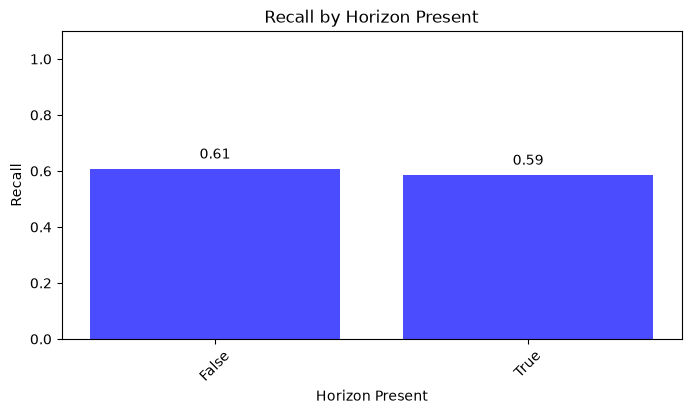

In [42]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='recall', title='Recall by Horizon Present', ylabel='Recall', xlabel='Horizon Present')


### Hit Rate


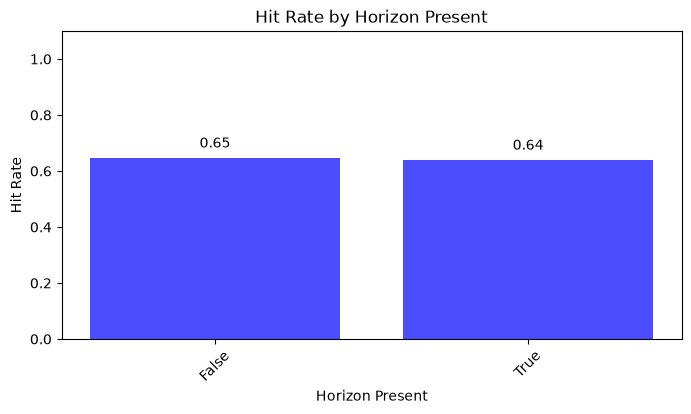

In [43]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='hit_rate', title='Hit Rate by Horizon Present', ylabel='Hit Rate', xlabel='Horizon Present')


### Diversity


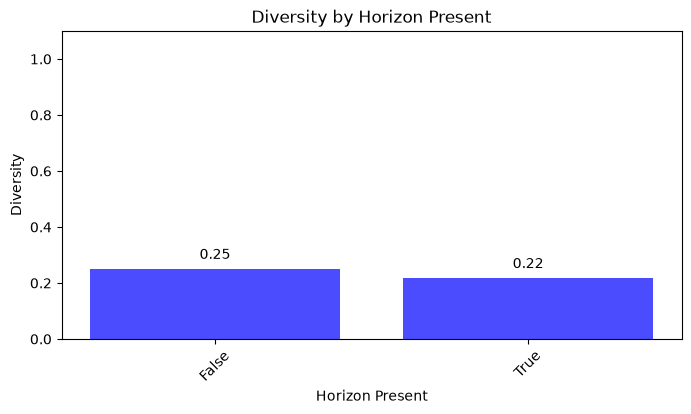

In [44]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='diversity', title='Diversity by Horizon Present', ylabel='Diversity', xlabel='Horizon Present')


### NDCG


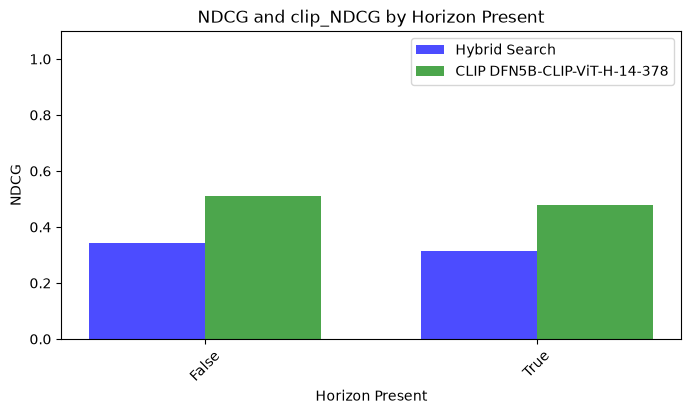

In [45]:
plot_rank_comparison(horizon_present_metrics, x_column='horizon_present', title='NDCG and clip_NDCG by Horizon Present', xlabel='Horizon Present')


### MRR


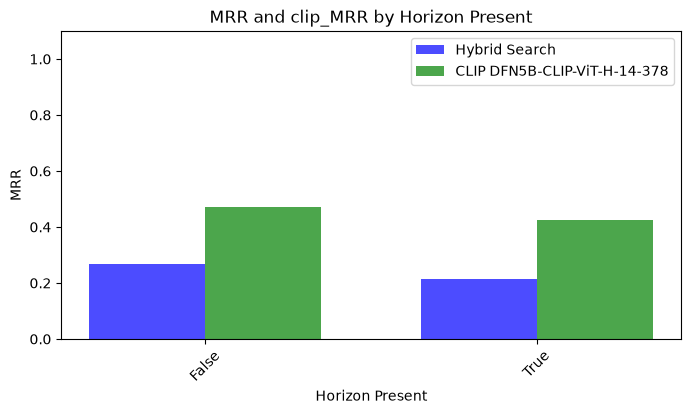

In [46]:
plot_rank_comparison(horizon_present_metrics, x_column='horizon_present', title='MRR and clip_MRR by Horizon Present', xlabel='Horizon Present', metric="MRR")


## Metrics based on Ground Present

Now, we will evaluate queries based on **Ground Present** (true vs false).


In [47]:
# Group by ground_present and calculate the sum/mean of each metric
ground_present_metrics = df.groupby('ground_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
ground_present_metrics['ground_present'] = ground_present_metrics['ground_present'].map({True: 'True', False: 'False'})


#rename columns
ground_present_metrics = ground_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
ground_present_metrics = ground_present_metrics.sort_values('ground_present')

ground_present_metrics


,ground_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,475,13,462,12,463,0.027368,0.025263,0.535088,0.578947,0.322828,0.444522,0.271037,0.410526,0.266636
1,True,2525,78,2447,69,2456,0.030891,0.027327,0.602640,0.653465,0.321768,0.494864,0.221872,0.443824,0.218404


### Accuracy


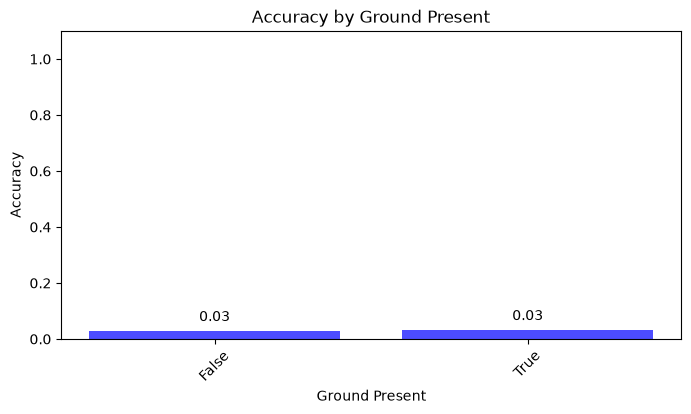

In [48]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='accuracy', title='Accuracy by Ground Present', ylabel='Accuracy', xlabel='Ground Present')


### Precision


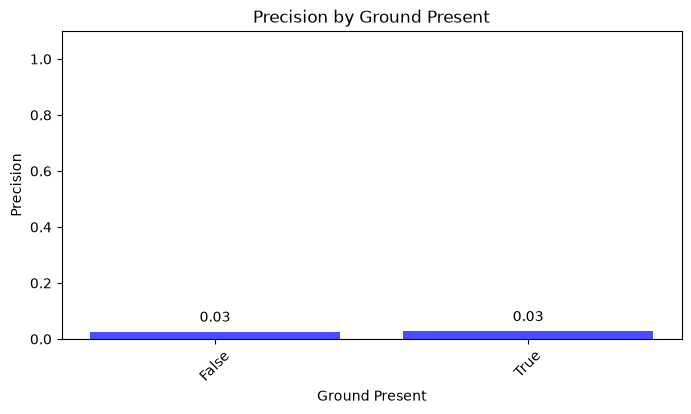

In [49]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='precision', title='Precision by Ground Present', ylabel='Precision', xlabel='Ground Present')


### Recall


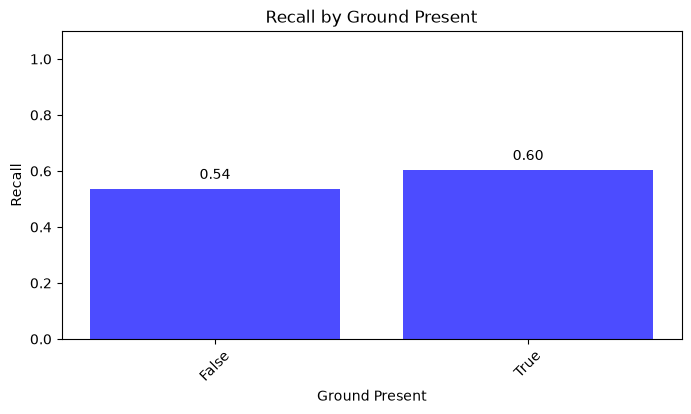

In [50]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='recall', title='Recall by Ground Present', ylabel='Recall', xlabel='Ground Present')


### Hit Rate


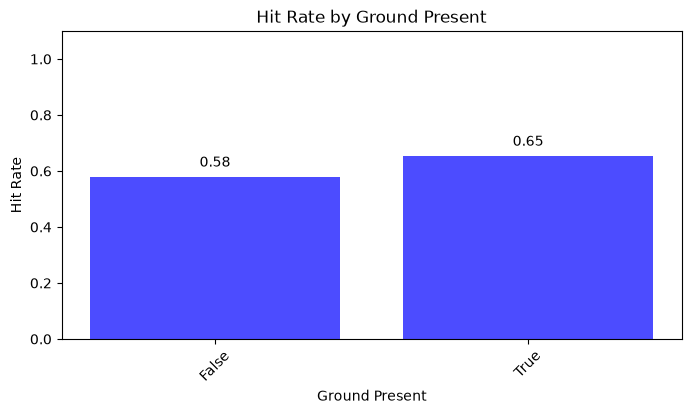

In [51]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='hit_rate', title='Hit Rate by Ground Present', ylabel='Hit Rate', xlabel='Ground Present')


### Diversity


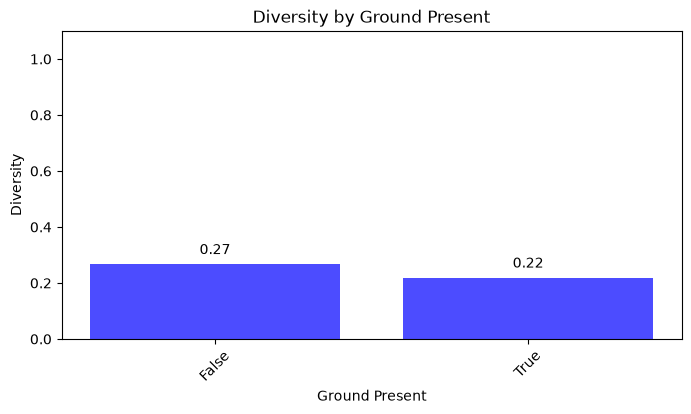

In [52]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='diversity', title='Diversity by Ground Present', ylabel='Diversity', xlabel='Ground Present')


### NDCG


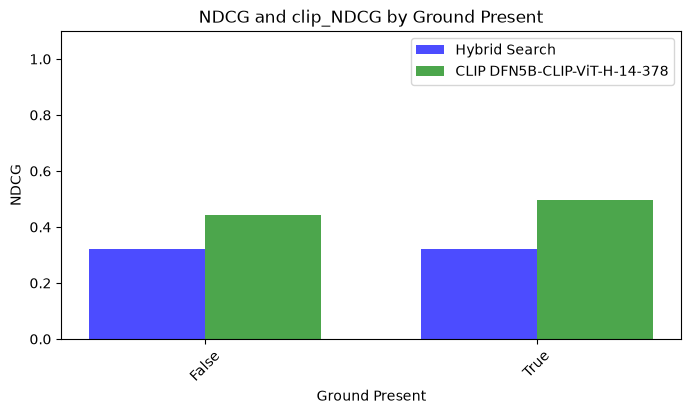

In [53]:
plot_rank_comparison(ground_present_metrics, x_column='ground_present', title='NDCG and clip_NDCG by Ground Present', xlabel='Ground Present')


### MRR


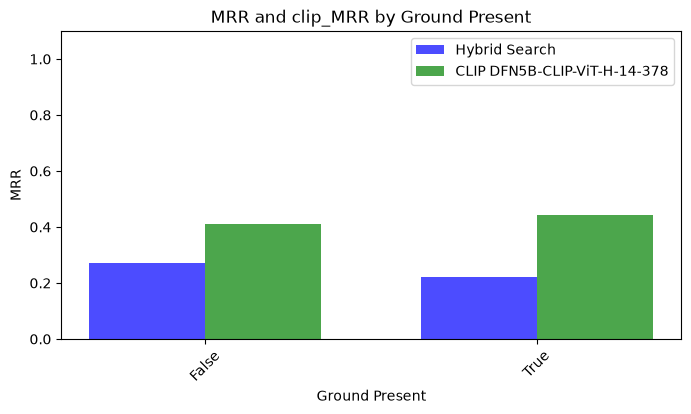

In [54]:
plot_rank_comparison(ground_present_metrics, x_column='ground_present', title='MRR and clip_MRR by Ground Present', xlabel='Ground Present', metric="MRR")


## Metrics based on Sky Dominates

Now, we will evaluate queries based on **Sky Dominates** (true vs false).


In [55]:
# Group by sky_dominates and calculate the sum/mean of each metric
sky_dominates_metrics = df.groupby('sky_dominates').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

sky_dominates_metrics['sky_dominates'] = sky_dominates_metrics['sky_dominates'].map({True: 'True', False: 'False'})

#rename columns
sky_dominates_metrics = sky_dominates_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
sky_dominates_metrics = sky_dominates_metrics.sort_values('sky_dominates')

sky_dominates_metrics


,sky_dominates,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1800,47,1753,42,1758,0.026111,0.023333,0.530093,0.555556,0.286269,0.427149,0.209217,0.389043,0.234399
1,True,1200,44,1156,39,1161,0.036667,0.032500,0.684722,0.770833,0.375435,0.576510,0.260316,0.512814,0.213502


### Accuracy


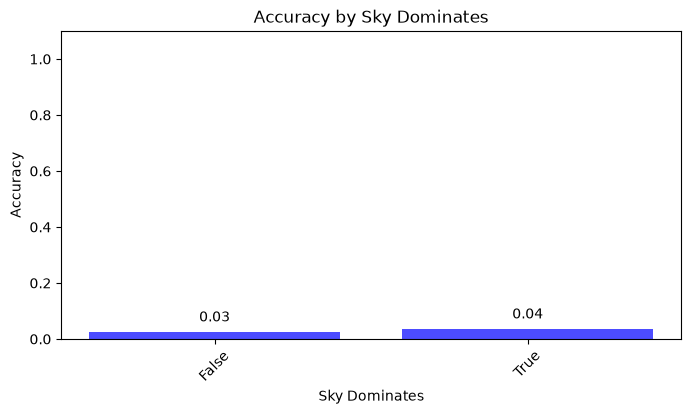

In [56]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='accuracy', title='Accuracy by Sky Dominates', ylabel='Accuracy', xlabel='Sky Dominates')


### Precision


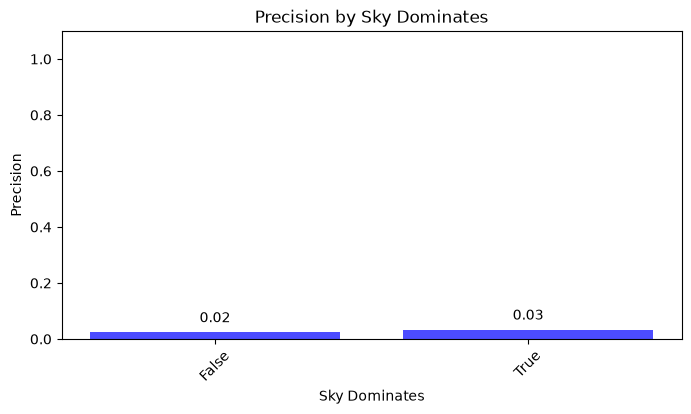

In [57]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='precision', title='Precision by Sky Dominates', ylabel='Precision', xlabel='Sky Dominates')


### Recall


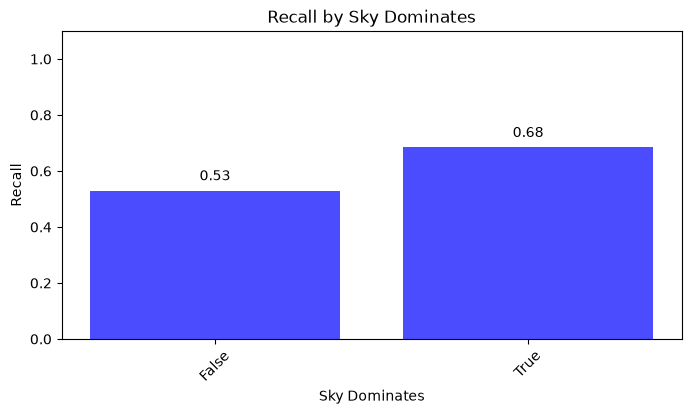

In [58]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='recall', title='Recall by Sky Dominates', ylabel='Recall', xlabel='Sky Dominates')


### Hit Rate


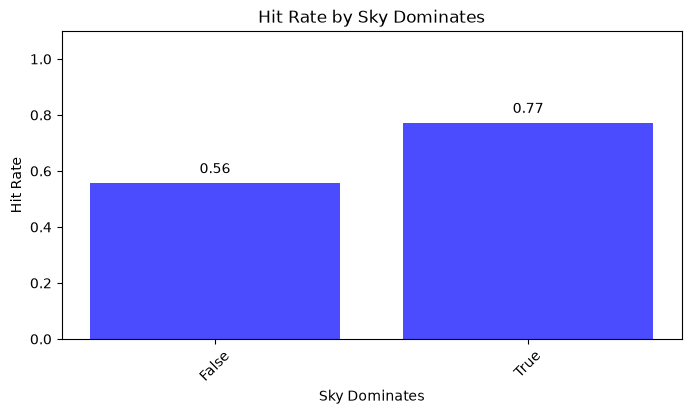

In [59]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='hit_rate', title='Hit Rate by Sky Dominates', ylabel='Hit Rate', xlabel='Sky Dominates')


### Diversity


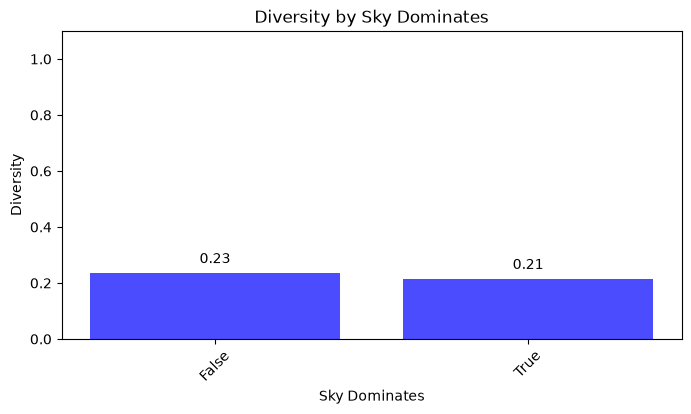

In [60]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='diversity', title='Diversity by Sky Dominates', ylabel='Diversity', xlabel='Sky Dominates')


### NDCG


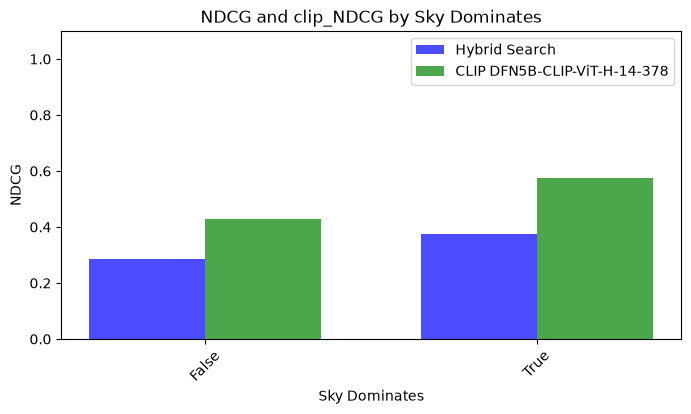

In [61]:
plot_rank_comparison(sky_dominates_metrics, x_column='sky_dominates', title='NDCG and clip_NDCG by Sky Dominates', xlabel='Sky Dominates')


### MRR


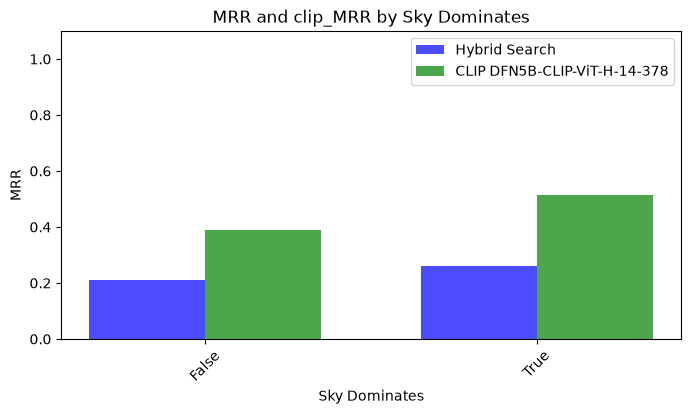

In [62]:
plot_rank_comparison(sky_dominates_metrics, x_column='sky_dominates', title='MRR and clip_MRR by Sky Dominates', xlabel='Sky Dominates', metric="MRR")


## Metrics based on Vegetation Present

Now, we will evaluate queries based on **Vegetation Present** (true vs false).


In [63]:
# Group by vegetation_present and calculate the sum/mean of each metric
vegetation_present_metrics = df.groupby('vegetation_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

vegetation_present_metrics['vegetation_present'] = vegetation_present_metrics['vegetation_present'].map({True: 'True', False: 'False'})


#rename columns
vegetation_present_metrics = vegetation_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
vegetation_present_metrics = vegetation_present_metrics.sort_values('vegetation_present')

vegetation_present_metrics


,vegetation_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1125,35,1090,32,1093,0.031111,0.028444,0.596296,0.666667,0.325077,0.498053,0.236941,0.448854,0.214917
1,True,1875,56,1819,49,1826,0.029867,0.026133,0.589333,0.626667,0.320051,0.480198,0.225286,0.432370,0.232714


### Accuracy


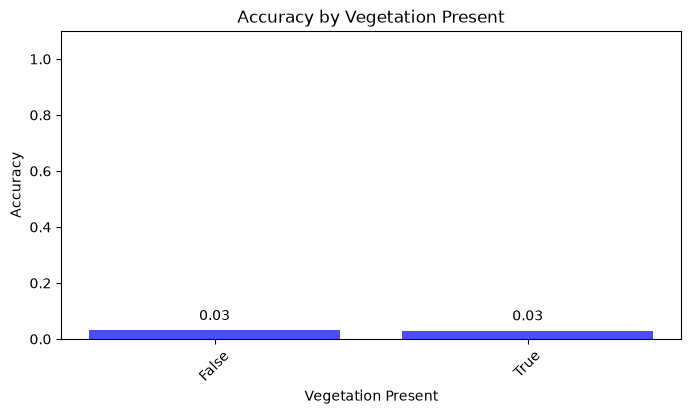

In [64]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='accuracy', title='Accuracy by Vegetation Present', ylabel='Accuracy', xlabel='Vegetation Present')


### Precision


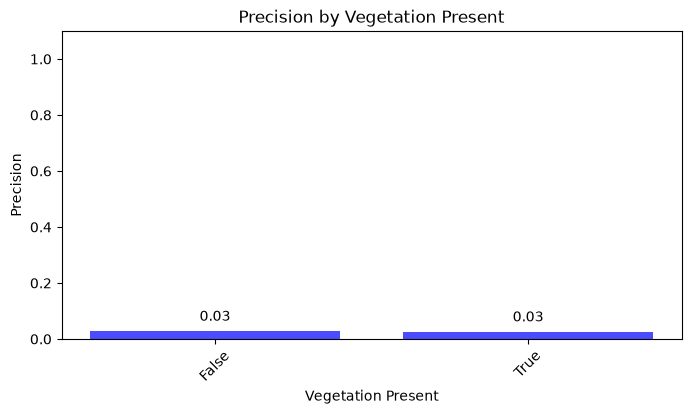

In [65]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='precision', title='Precision by Vegetation Present', ylabel='Precision', xlabel='Vegetation Present')


### Recall


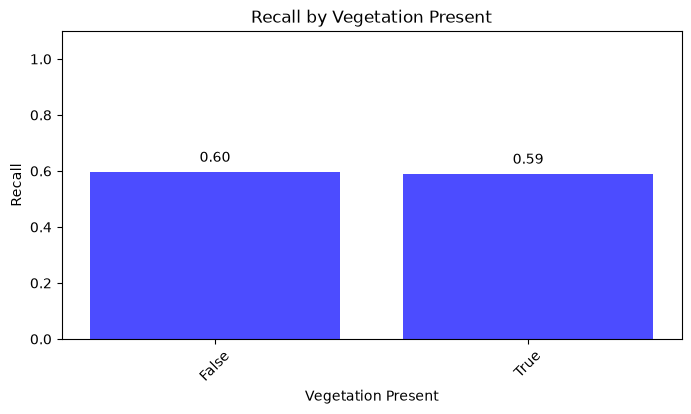

In [66]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='recall', title='Recall by Vegetation Present', ylabel='Recall', xlabel='Vegetation Present')


### Hit Rate


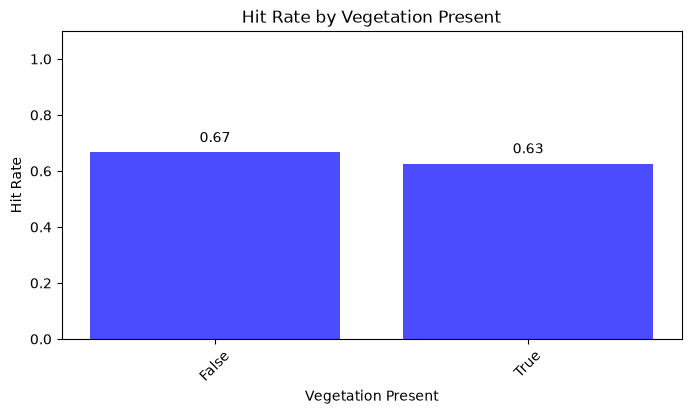

In [67]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='hit_rate', title='Hit Rate by Vegetation Present', ylabel='Hit Rate', xlabel='Vegetation Present')


### Diversity


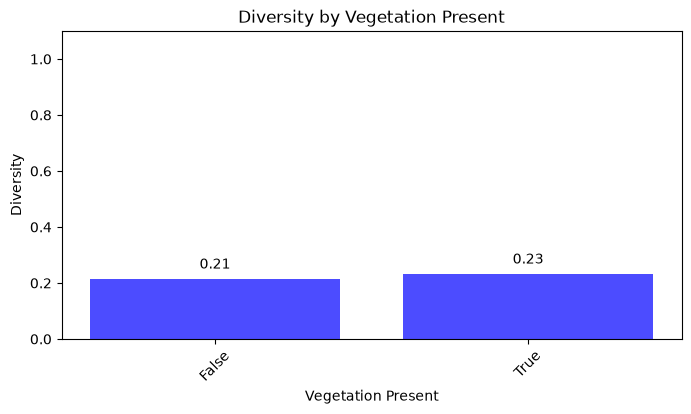

In [68]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='diversity', title='Diversity by Vegetation Present', ylabel='Diversity', xlabel='Vegetation Present')


### NDCG


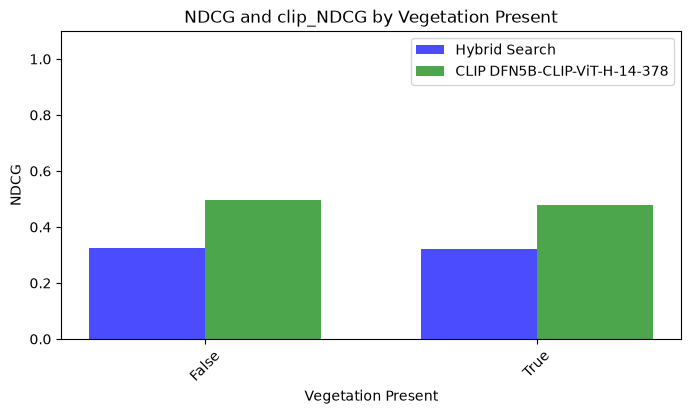

In [69]:
plot_rank_comparison(vegetation_present_metrics, x_column='vegetation_present', title='NDCG and clip_NDCG by Vegetation Present', xlabel='Vegetation Present')


### MRR


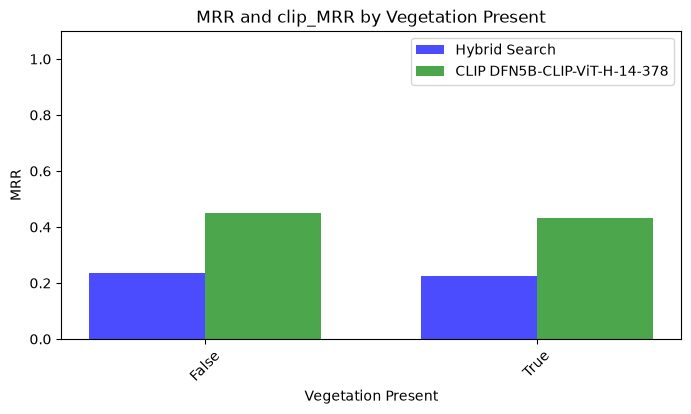

In [70]:
plot_rank_comparison(vegetation_present_metrics, x_column='vegetation_present', title='MRR and clip_MRR by Vegetation Present', xlabel='Vegetation Present', metric="MRR")


## Metrics based on Water Present

Now, we will evaluate queries based on **Water Present** (true vs false).


In [71]:
# Group by water_present and calculate the sum/mean of each metric
water_present_metrics = df.groupby('water_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

water_present_metrics['water_present'] = water_present_metrics['water_present'].map({True: 'True', False: 'False'})

#rename columns
water_present_metrics = water_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
water_present_metrics = water_present_metrics.sort_values('water_present')

water_present_metrics


,water_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2825,83,2742,74,2751,0.029381,0.026195,0.566667,0.619469,0.301682,0.467837,0.217355,0.420733,0.218442
1,True,175,8,167,7,168,0.045714,0.040000,1.000000,1.000000,0.648886,0.794515,0.428231,0.726190,0.348707


### Accuracy


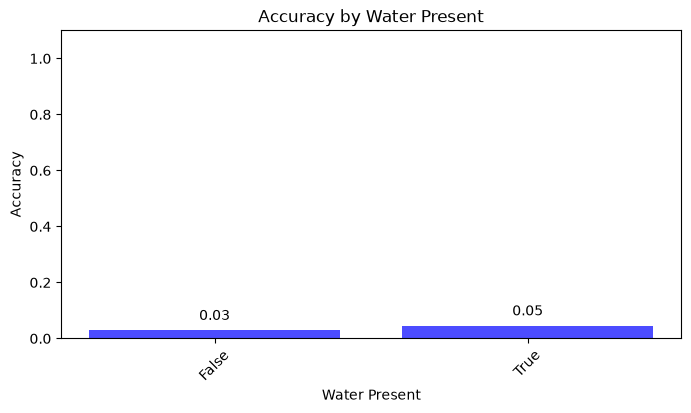

In [72]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='accuracy', title='Accuracy by Water Present', ylabel='Accuracy', xlabel='Water Present')


### Precision


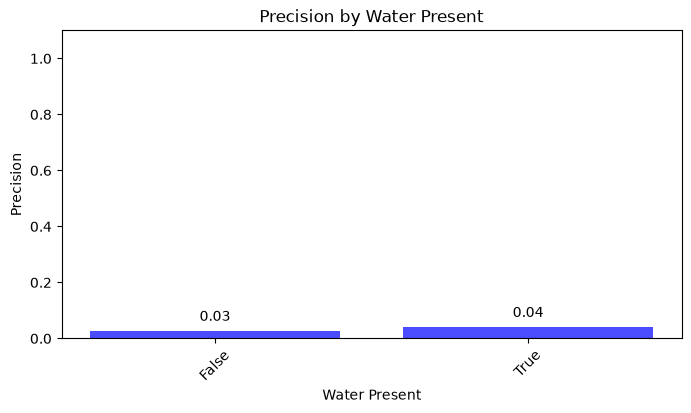

In [73]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='precision', title='Precision by Water Present', ylabel='Precision', xlabel='Water Present')


### Recall


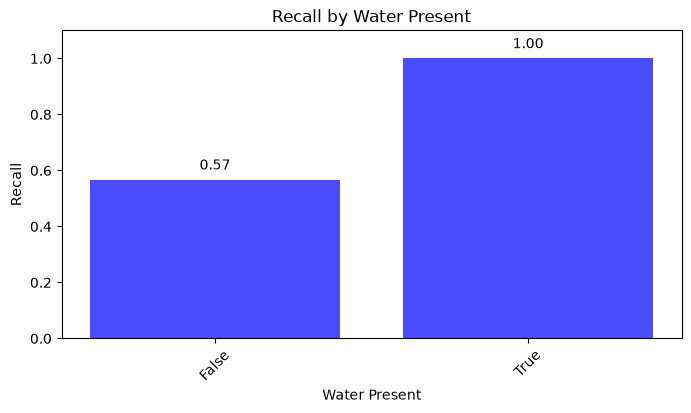

In [74]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='recall', title='Recall by Water Present', ylabel='Recall', xlabel='Water Present')


### Hit Rate


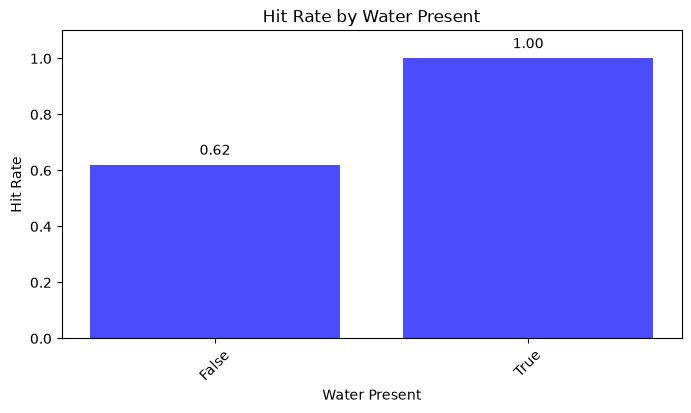

In [75]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='hit_rate', title='Hit Rate by Water Present', ylabel='Hit Rate', xlabel='Water Present')


### Diversity


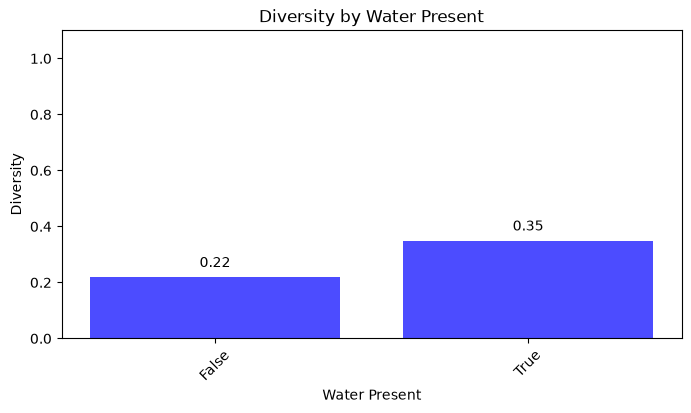

In [76]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='diversity', title='Diversity by Water Present', ylabel='Diversity', xlabel='Water Present')


### NDCG


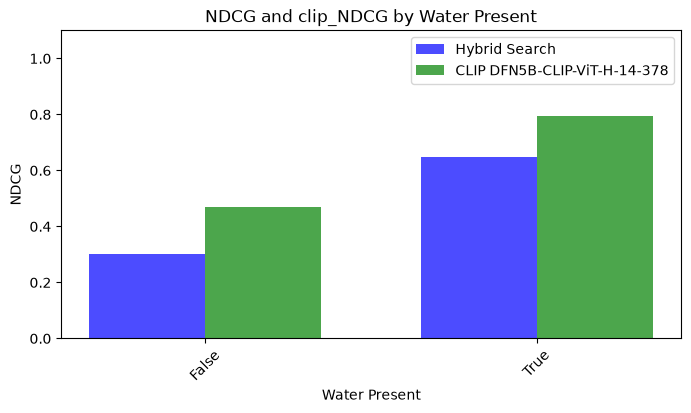

In [77]:
plot_rank_comparison(water_present_metrics, x_column='water_present', title='NDCG and clip_NDCG by Water Present', xlabel='Water Present')


### MRR


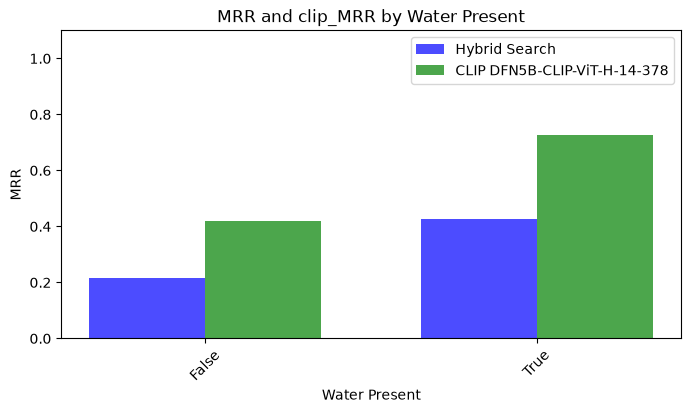

In [78]:
plot_rank_comparison(water_present_metrics, x_column='water_present', title='MRR and clip_MRR by Water Present', xlabel='Water Present', metric="MRR")


## Metrics based on Buildings Present

Now, we will evaluate queries based on **Buildings Present** (true vs false).


In [79]:
# Group by buildings_present and calculate the sum/mean of each metric
buildings_present_metrics = df.groupby('buildings_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

buildings_present_metrics['buildings_present'] = buildings_present_metrics['buildings_present'].map({True: 'True', False: 'False'})

#rename columns
buildings_present_metrics = buildings_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
buildings_present_metrics = buildings_present_metrics.sort_values('buildings_present')

buildings_present_metrics


,buildings_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1950,50,1900,45,1905,0.025641,0.023077,0.487607,0.538462,0.270406,0.401284,0.193847,0.361447,0.231407
1,True,1050,41,1009,36,1014,0.039048,0.034286,0.785714,0.833333,0.417633,0.645883,0.296159,0.581746,0.216073


### Accuracy


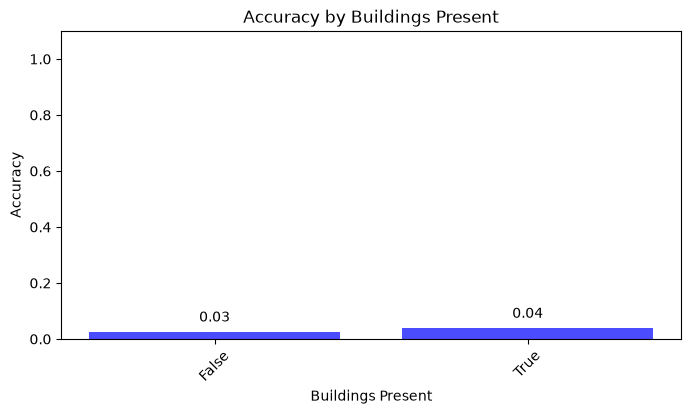

In [80]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='accuracy', title='Accuracy by Buildings Present', ylabel='Accuracy', xlabel='Buildings Present')


### Precision


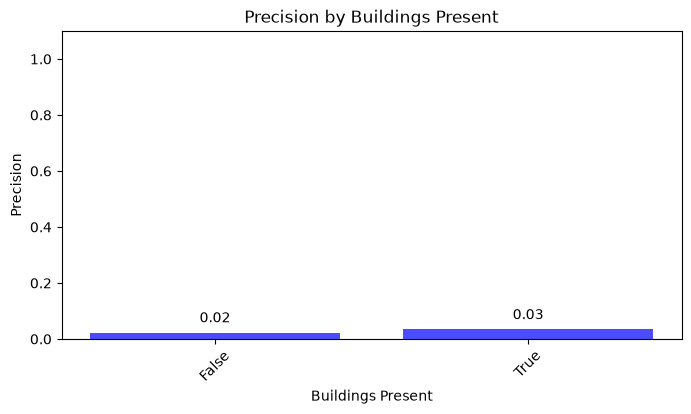

In [81]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='precision', title='Precision by Buildings Present', ylabel='Precision', xlabel='Buildings Present')


### Recall


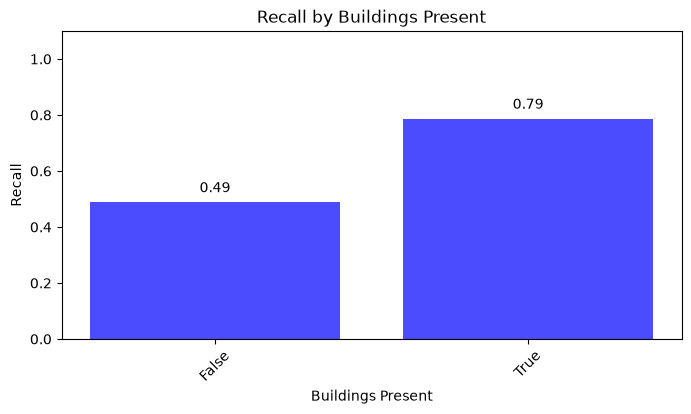

In [82]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='recall', title='Recall by Buildings Present', ylabel='Recall', xlabel='Buildings Present')


### Hit Rate


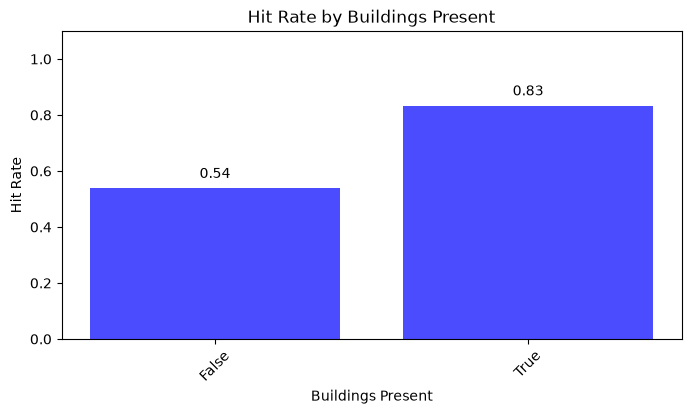

In [83]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='hit_rate', title='Hit Rate by Buildings Present', ylabel='Hit Rate', xlabel='Buildings Present')


### Diversity


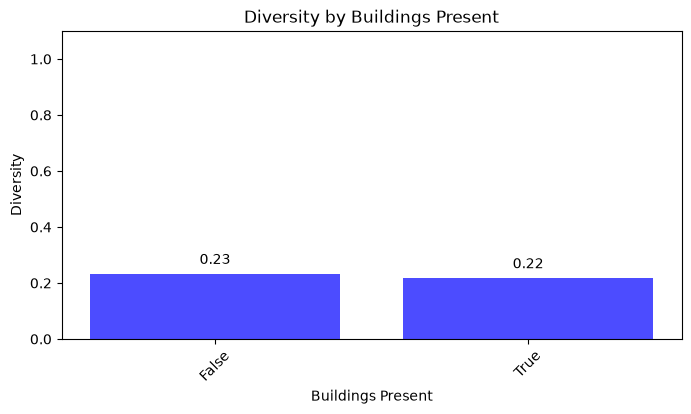

In [84]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='diversity', title='Diversity by Buildings Present', ylabel='Diversity', xlabel='Buildings Present')


### NDCG


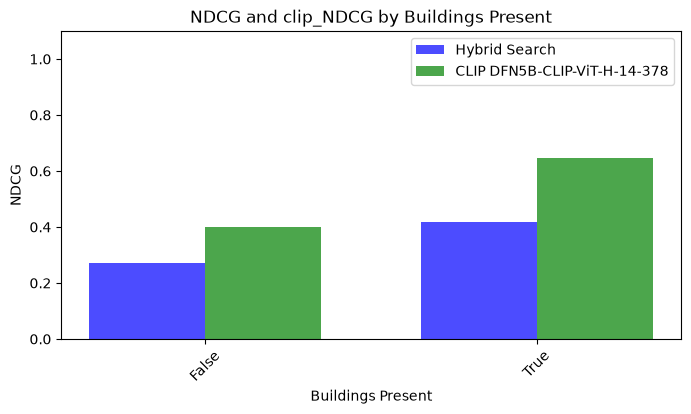

In [85]:
plot_rank_comparison(buildings_present_metrics, x_column='buildings_present', title='NDCG and clip_NDCG by Buildings Present', xlabel='Buildings Present')


### MRR


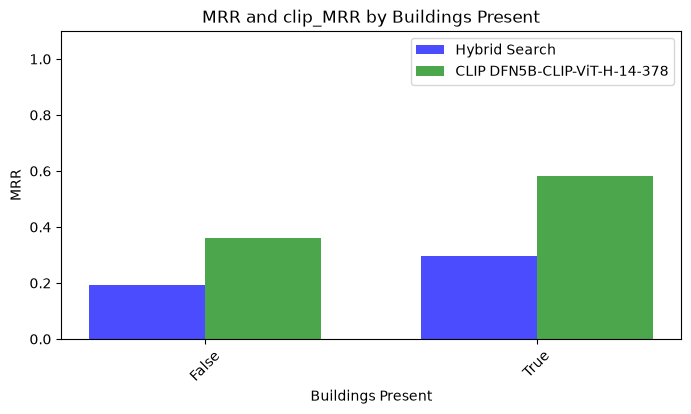

In [86]:
plot_rank_comparison(buildings_present_metrics, x_column='buildings_present', title='MRR and clip_MRR by Buildings Present', xlabel='Buildings Present', metric="MRR")


## Metrics based on Vehicle Present

Now, we will evaluate queries based on **Vehicle Present** (true vs false).


In [87]:
# Group by vehicle_present and calculate the sum/mean of each metric
vehicle_present_metrics = df.groupby('vehicle_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

vehicle_present_metrics['vehicle_present'] = vehicle_present_metrics['vehicle_present'].map({True: 'True', False: 'False'})


#rename columns
vehicle_present_metrics = vehicle_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
vehicle_present_metrics = vehicle_present_metrics.sort_values('vehicle_present')

vehicle_present_metrics


,vehicle_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2850,83,2767,74,2776,0.029123,0.025965,0.570468,0.622807,0.313785,0.469641,0.225735,0.422598,0.222333
1,True,150,8,142,7,143,0.053333,0.046667,1.000000,1.000000,0.476793,0.814686,0.304167,0.741667,0.296487


### Accuracy


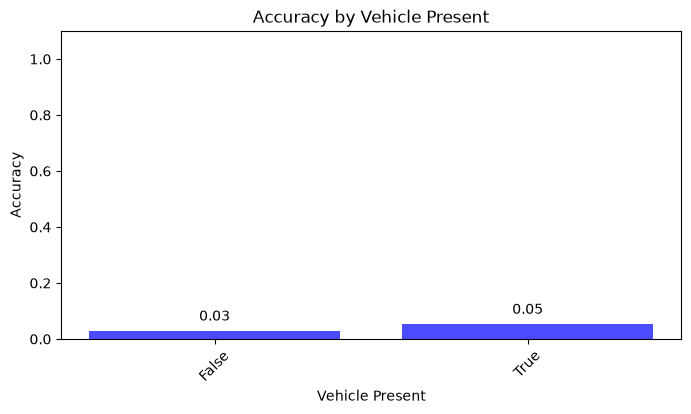

In [88]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='accuracy', title='Accuracy by Vehicle Present', ylabel='Accuracy', xlabel='Vehicle Present')


### Precision


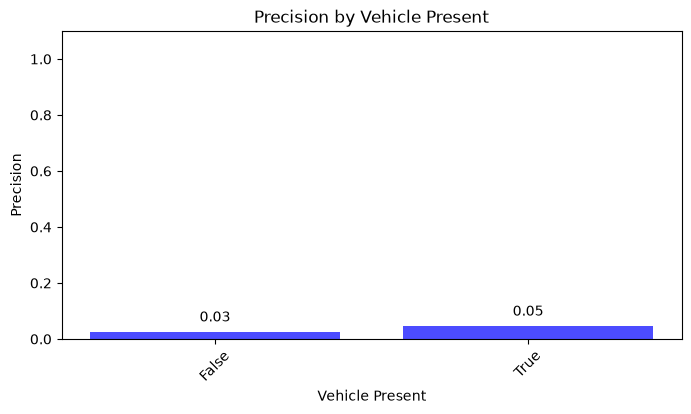

In [89]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='precision', title='Precision by Vehicle Present', ylabel='Precision', xlabel='Vehicle Present')


### Recall


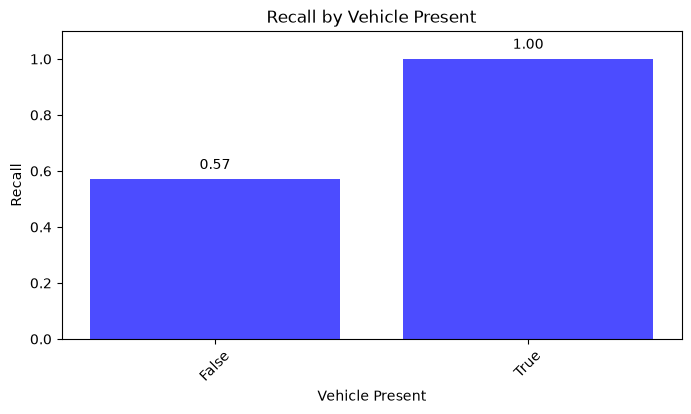

In [90]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='recall', title='Recall by Vehicle Present', ylabel='Recall', xlabel='Vehicle Present')


### Hit Rate


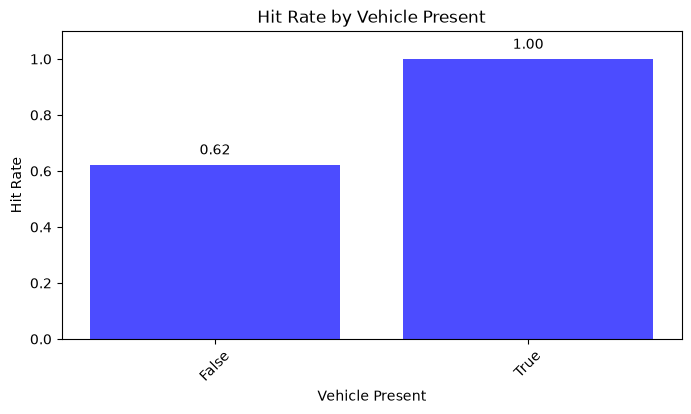

In [91]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='hit_rate', title='Hit Rate by Vehicle Present', ylabel='Hit Rate', xlabel='Vehicle Present')


### Diversity


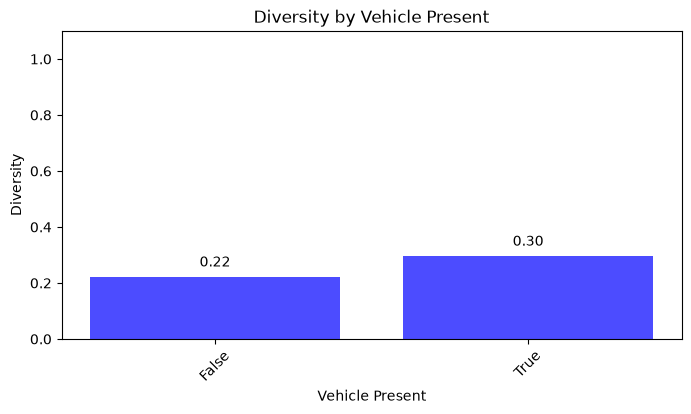

In [92]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='diversity', title='Diversity by Vehicle Present', ylabel='Diversity', xlabel='Vehicle Present')


### NDCG


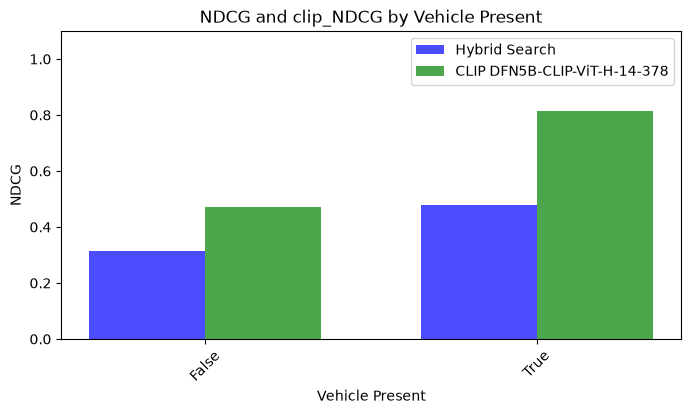

In [93]:
plot_rank_comparison(vehicle_present_metrics, x_column='vehicle_present', title='NDCG and clip_NDCG by Vehicle Present', xlabel='Vehicle Present')


### MRR


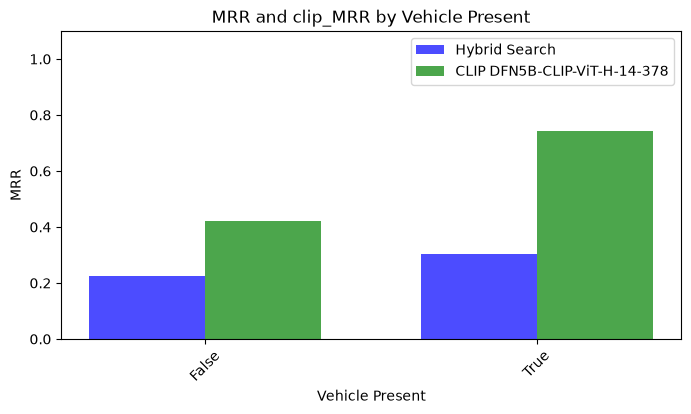

In [94]:
plot_rank_comparison(vehicle_present_metrics, x_column='vehicle_present', title='MRR and clip_MRR by Vehicle Present', xlabel='Vehicle Present', metric="MRR")


## Metrics based on Person Present

Now, we will evaluate queries based on **Person Present** (true vs false).


In [95]:
# Group by person_present and calculate the sum/mean of each metric
person_present_metrics = df.groupby('person_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

person_present_metrics['person_present'] = person_present_metrics['person_present'].map({True: 'True', False: 'False'})

#rename columns
person_present_metrics = person_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
person_present_metrics = person_present_metrics.sort_values('person_present')

person_present_metrics


,person_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,3000,91,2909,81,2919,0.030333,0.027,0.591944,0.641667,0.321936,0.486894,0.229657,0.438552,0.22604


### Accuracy


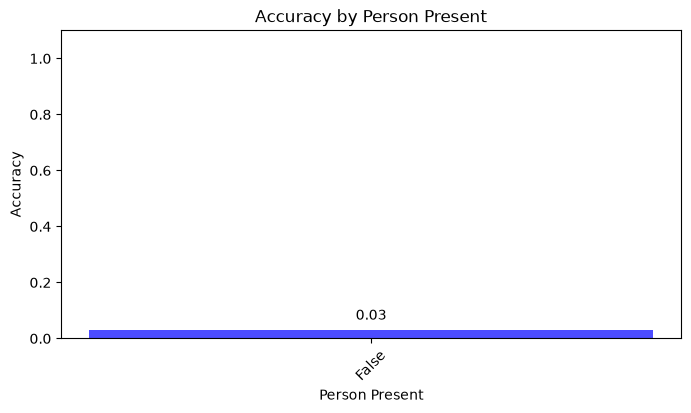

In [96]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='accuracy', title='Accuracy by Person Present', ylabel='Accuracy', xlabel='Person Present')


### Precision


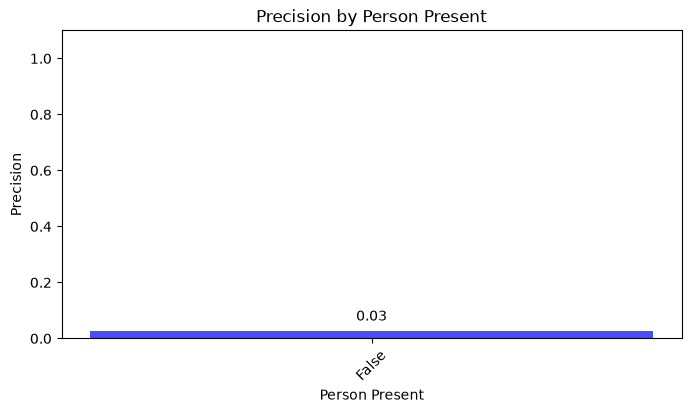

In [97]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='precision', title='Precision by Person Present', ylabel='Precision', xlabel='Person Present')


### Recall


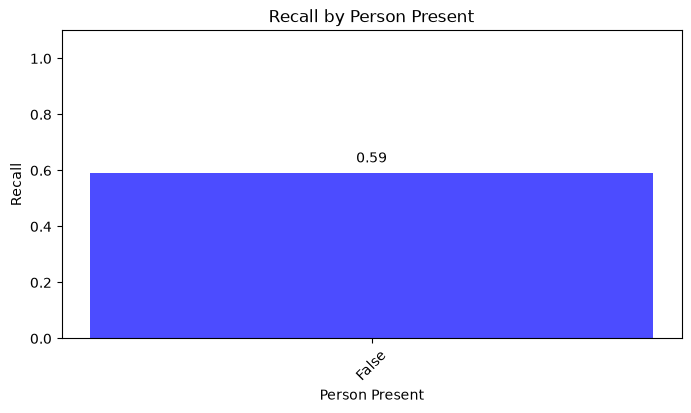

In [98]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='recall', title='Recall by Person Present', ylabel='Recall', xlabel='Person Present')


### Hit Rate


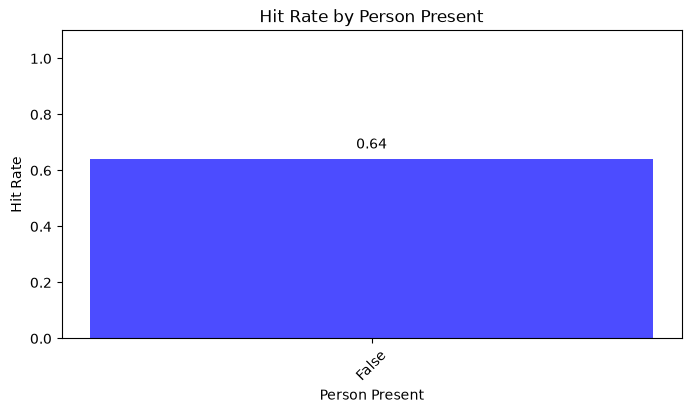

In [99]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='hit_rate', title='Hit Rate by Person Present', ylabel='Hit Rate', xlabel='Person Present')


### Diversity


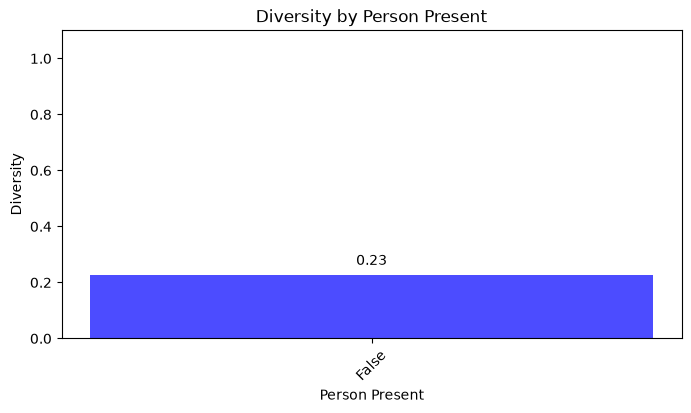

In [100]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='diversity', title='Diversity by Person Present', ylabel='Diversity', xlabel='Person Present')


### NDCG


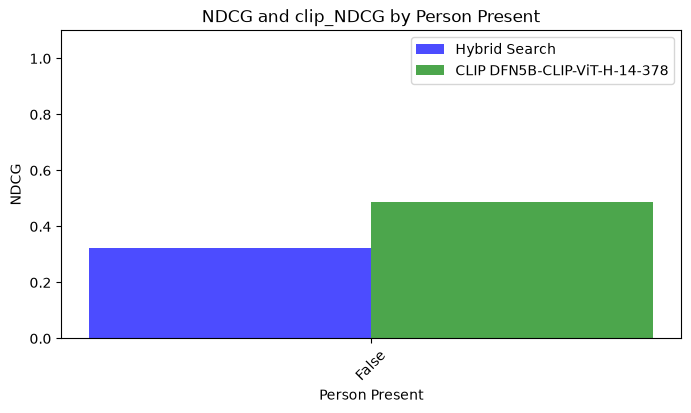

In [101]:
plot_rank_comparison(person_present_metrics, x_column='person_present', title='NDCG and clip_NDCG by Person Present', xlabel='Person Present')


### MRR


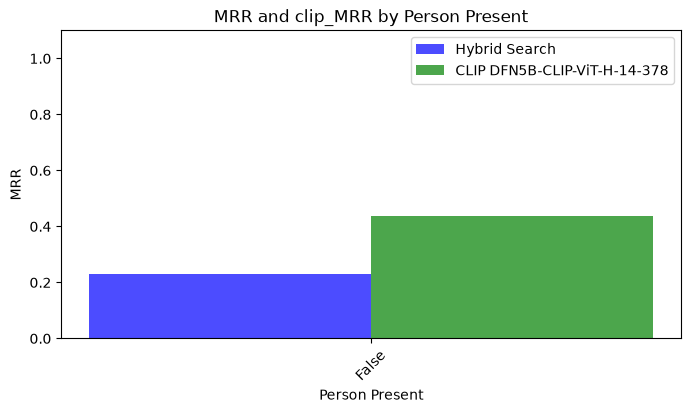

In [102]:
plot_rank_comparison(person_present_metrics, x_column='person_present', title='MRR and clip_MRR by Person Present', xlabel='Person Present', metric="MRR")


## Metrics based on Animal Present

Now, we will evaluate queries based on **Animal Present** (true vs false).


In [103]:
# Group by animal_present and calculate the sum/mean of each metric
animal_present_metrics = df.groupby('animal_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

animal_present_metrics['animal_present'] = animal_present_metrics['animal_present'].map({True: 'True', False: 'False'})

#rename columns
animal_present_metrics = animal_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
animal_present_metrics = animal_present_metrics.sort_values('animal_present')

animal_present_metrics


,animal_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,3000,91,2909,81,2919,0.030333,0.027,0.591944,0.641667,0.321936,0.486894,0.229657,0.438552,0.22604


### Accuracy


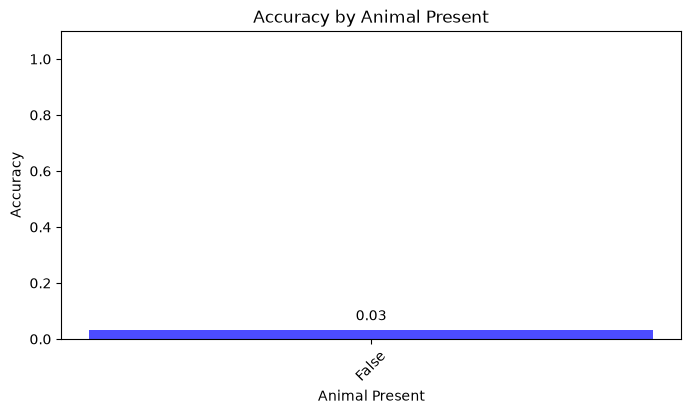

In [104]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='accuracy', title='Accuracy by Animal Present', ylabel='Accuracy', xlabel='Animal Present')


### Precision


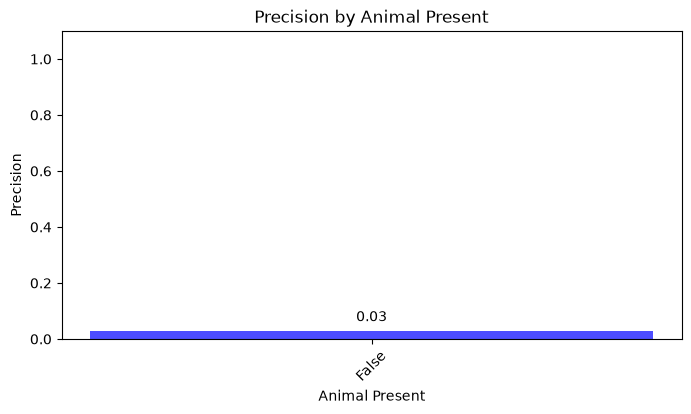

In [105]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='precision', title='Precision by Animal Present', ylabel='Precision', xlabel='Animal Present')


### Recall


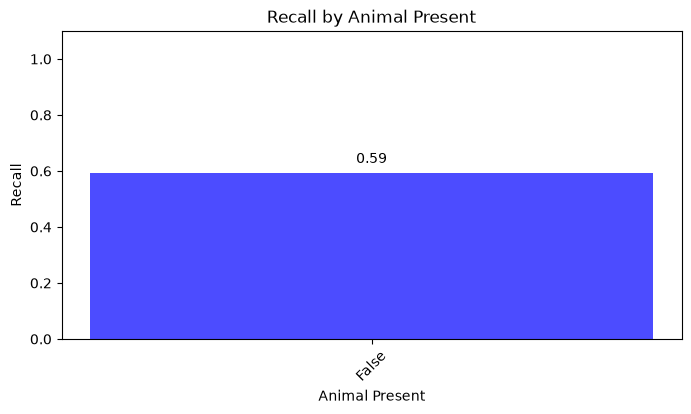

In [106]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='recall', title='Recall by Animal Present', ylabel='Recall', xlabel='Animal Present')


### Hit Rate


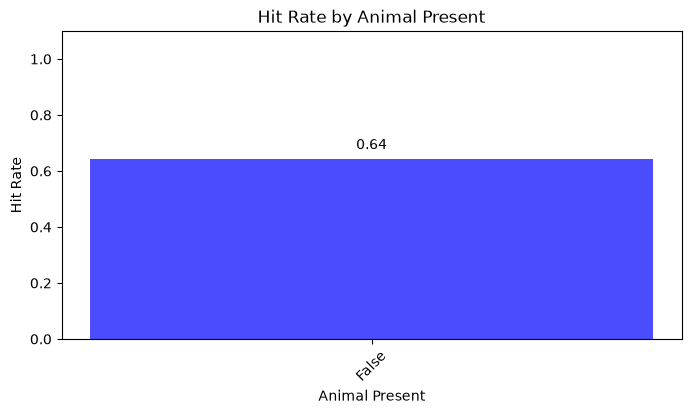

In [107]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='hit_rate', title='Hit Rate by Animal Present', ylabel='Hit Rate', xlabel='Animal Present')


### Diversity


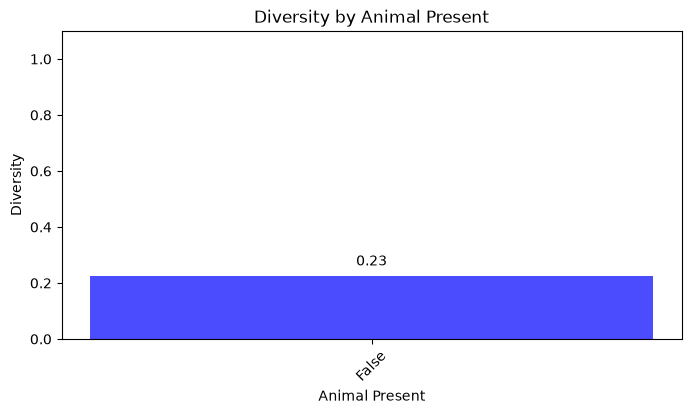

In [108]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='diversity', title='Diversity by Animal Present', ylabel='Diversity', xlabel='Animal Present')


### NDCG


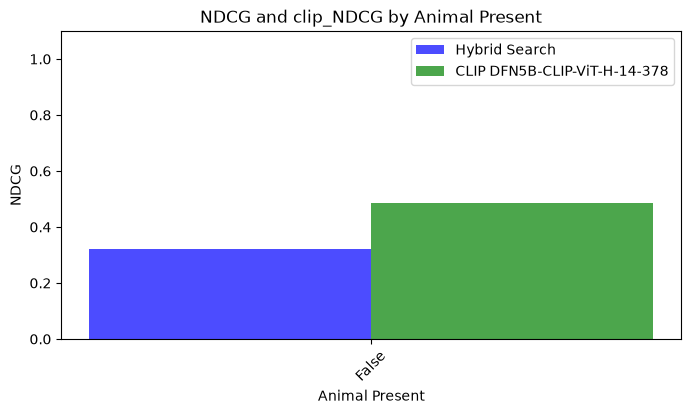

In [109]:
plot_rank_comparison(animal_present_metrics, x_column='animal_present', title='NDCG and clip_NDCG by Animal Present', xlabel='Animal Present')


### MRR


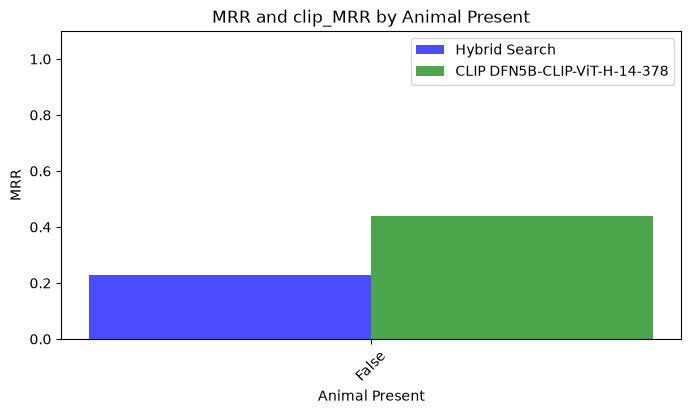

In [110]:
plot_rank_comparison(animal_present_metrics, x_column='animal_present', title='MRR and clip_MRR by Animal Present', xlabel='Animal Present', metric="MRR")


## Metrics based on Night Scene

Now, we will evaluate queries based on **Night Scene** (true vs false).


In [111]:
# Group by night_scene and calculate the sum/mean of each metric
night_scene_metrics = df.groupby('night_scene').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

night_scene_metrics['night_scene'] = night_scene_metrics['night_scene'].map({True: 'True', False: 'False'})

#rename columns
night_scene_metrics = night_scene_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
night_scene_metrics = night_scene_metrics.sort_values('night_scene')

night_scene_metrics


,night_scene,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1975,62,1913,54,1921,0.031392,0.027342,0.593249,0.658228,0.342149,0.516127,0.238789,0.467511,0.213452
1,True,1025,29,996,27,998,0.028293,0.026341,0.589431,0.609756,0.282989,0.430567,0.212060,0.382753,0.250296


### Accuracy


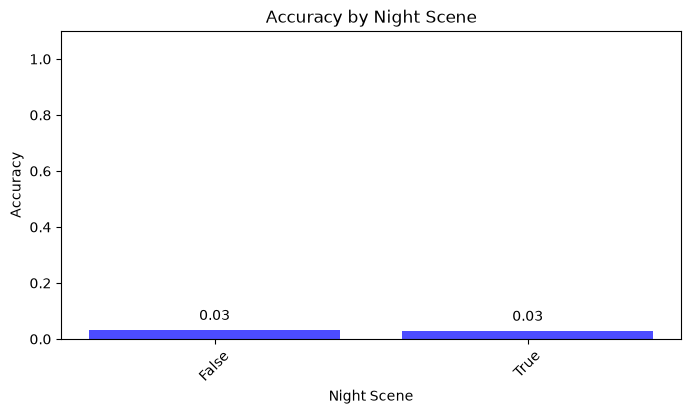

In [112]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='accuracy', title='Accuracy by Night Scene', ylabel='Accuracy', xlabel='Night Scene')


### Precision


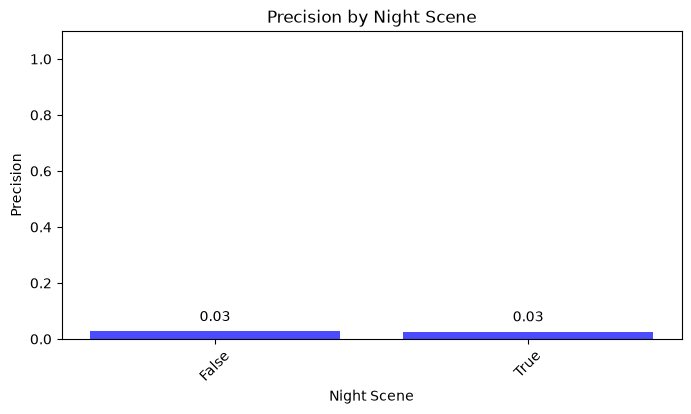

In [113]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='precision', title='Precision by Night Scene', ylabel='Precision', xlabel='Night Scene')


### Recall


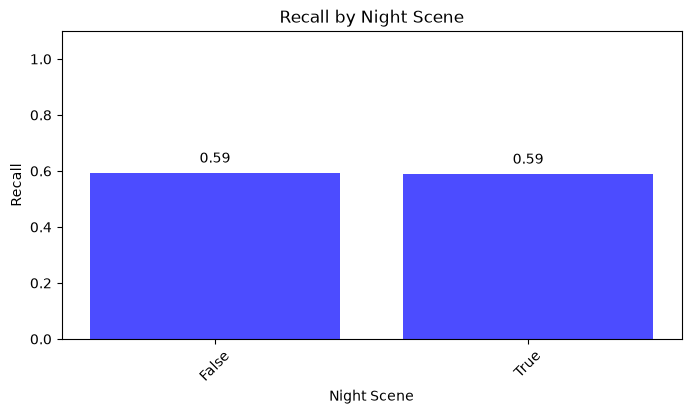

In [114]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='recall', title='Recall by Night Scene', ylabel='Recall', xlabel='Night Scene')


### Hit Rate


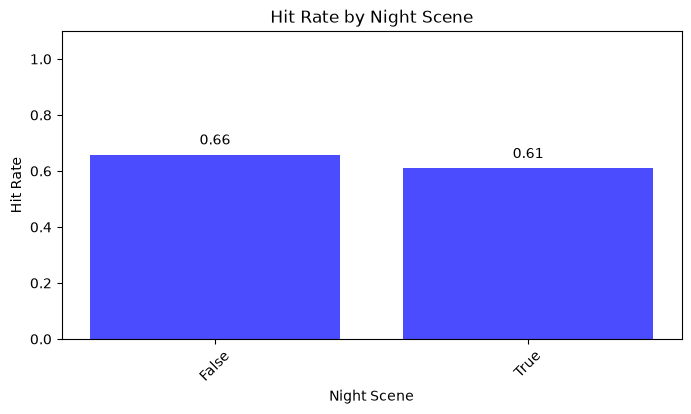

In [115]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='hit_rate', title='Hit Rate by Night Scene', ylabel='Hit Rate', xlabel='Night Scene')


### Diversity


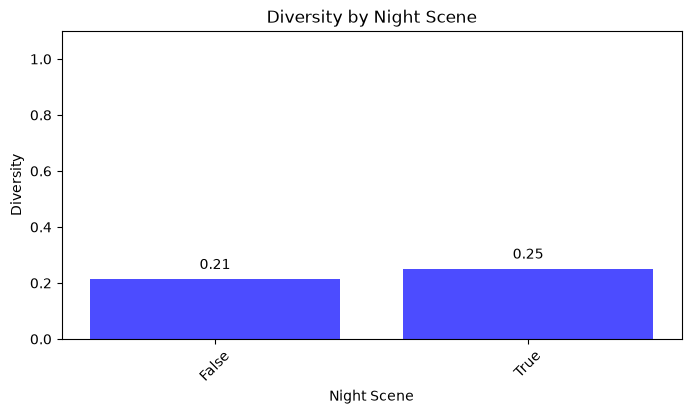

In [116]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='diversity', title='Diversity by Night Scene', ylabel='Diversity', xlabel='Night Scene')


### NDCG


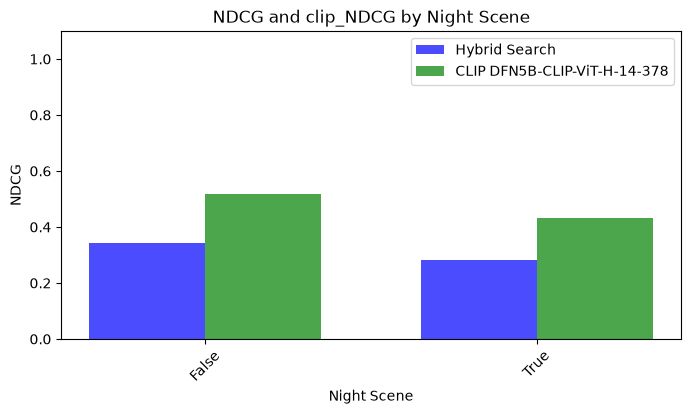

In [117]:
plot_rank_comparison(night_scene_metrics, x_column='night_scene', title='NDCG and clip_NDCG by Night Scene', xlabel='Night Scene')


### MRR


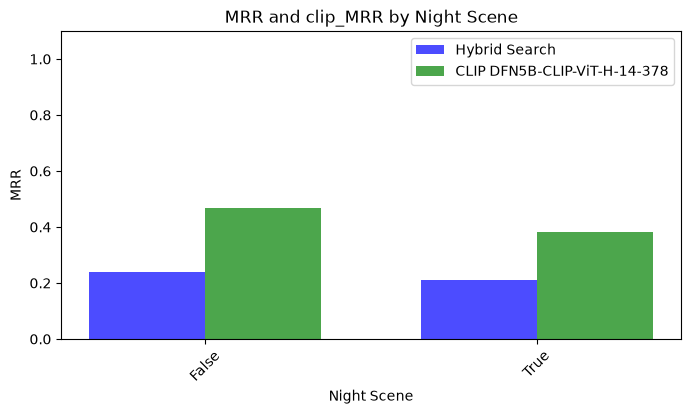

In [118]:
plot_rank_comparison(night_scene_metrics, x_column='night_scene', title='MRR and clip_MRR by Night Scene', xlabel='Night Scene', metric="MRR")


## Metrics based on Precipitation Visible

Now, we will evaluate queries based on **Precipitation Visible** (true vs false).


In [119]:
# Group by precipitation_visible and calculate the sum/mean of each metric
precipitation_visible_metrics = df.groupby('precipitation_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

precipitation_visible_metrics['precipitation_visible'] = precipitation_visible_metrics['precipitation_visible'].map({True: 'True', False: 'False'})

#rename columns
precipitation_visible_metrics = precipitation_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
precipitation_visible_metrics = precipitation_visible_metrics.sort_values('precipitation_visible')

precipitation_visible_metrics


,precipitation_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2900,88,2812,78,2822,0.030345,0.026897,0.586494,0.637931,0.324450,0.485911,0.233768,0.438588,0.227325
1,True,100,3,97,3,97,0.030000,0.030000,0.750000,0.750000,0.249035,0.515402,0.110417,0.437500,0.188783


### Accuracy


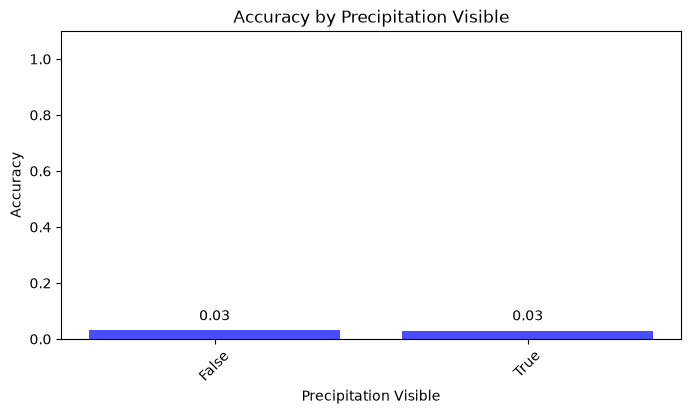

In [120]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='accuracy', title='Accuracy by Precipitation Visible', ylabel='Accuracy', xlabel='Precipitation Visible')


### Precision


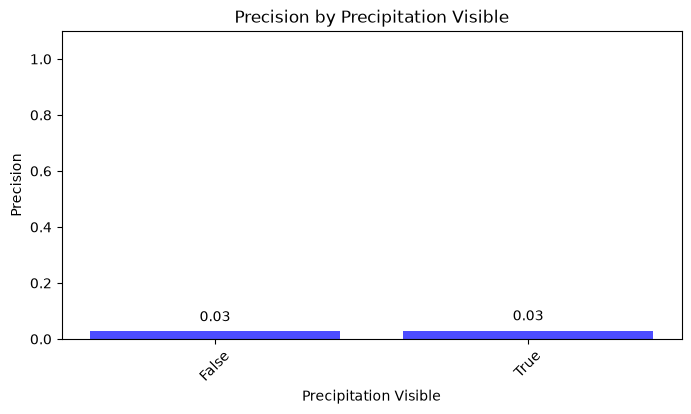

In [121]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='precision', title='Precision by Precipitation Visible', ylabel='Precision', xlabel='Precipitation Visible')


### Recall


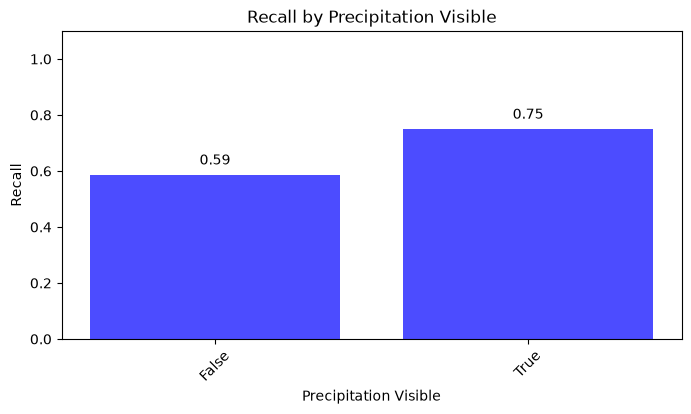

In [122]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='recall', title='Recall by Precipitation Visible', ylabel='Recall', xlabel='Precipitation Visible')


### Hit Rate


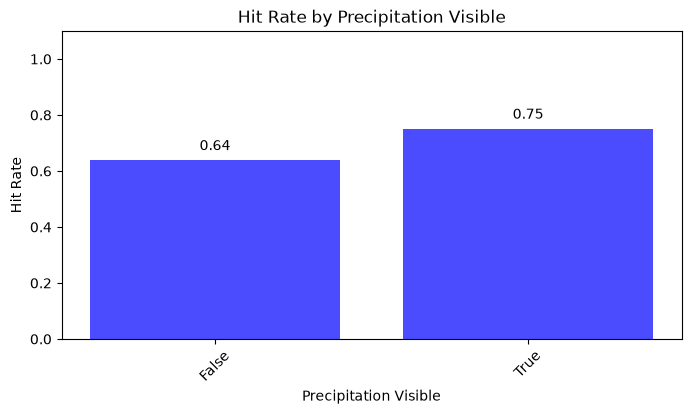

In [123]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='hit_rate', title='Hit Rate by Precipitation Visible', ylabel='Hit Rate', xlabel='Precipitation Visible')


### Diversity


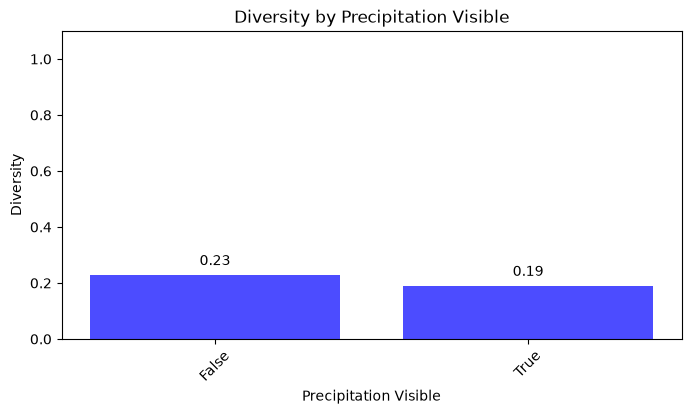

In [124]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='diversity', title='Diversity by Precipitation Visible', ylabel='Diversity', xlabel='Precipitation Visible')


### NDCG


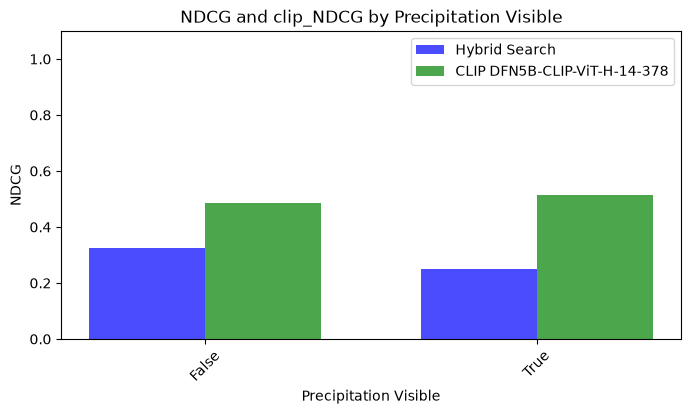

In [125]:
plot_rank_comparison(precipitation_visible_metrics, x_column='precipitation_visible', title='NDCG and clip_NDCG by Precipitation Visible', xlabel='Precipitation Visible')


### MRR


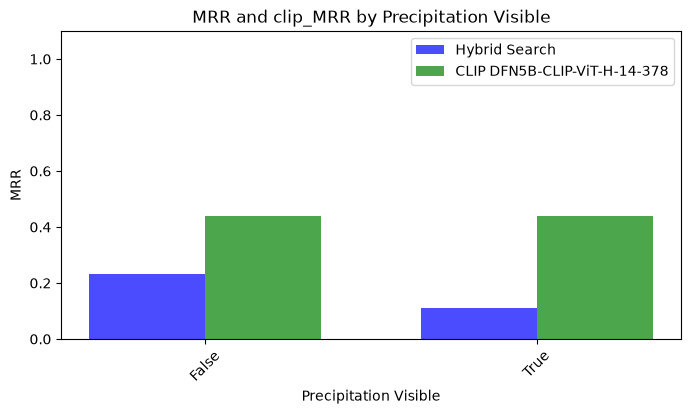

In [126]:
plot_rank_comparison(precipitation_visible_metrics, x_column='precipitation_visible', title='MRR and clip_MRR by Precipitation Visible', xlabel='Precipitation Visible', metric="MRR")


## Metrics based on Multiple Objects

Now, we will evaluate queries based on **Multiple Objects** (true vs false).


In [127]:
# Group by multiple_objects and calculate the sum/mean of each metric
multiple_objects_metrics = df.groupby('multiple_objects').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

multiple_objects_metrics['multiple_objects'] = multiple_objects_metrics['multiple_objects'].map({True: 'True', False: 'False'})

#rename columns
multiple_objects_metrics = multiple_objects_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
multiple_objects_metrics = multiple_objects_metrics.sort_values('multiple_objects')

multiple_objects_metrics


,multiple_objects,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,250,7,243,7,243,0.028000,0.028000,0.566667,0.600000,0.201248,0.388647,0.134415,0.344286,0.308791
1,True,2750,84,2666,74,2676,0.030545,0.026909,0.594242,0.645455,0.332907,0.495825,0.238315,0.447121,0.218518


### Accuracy


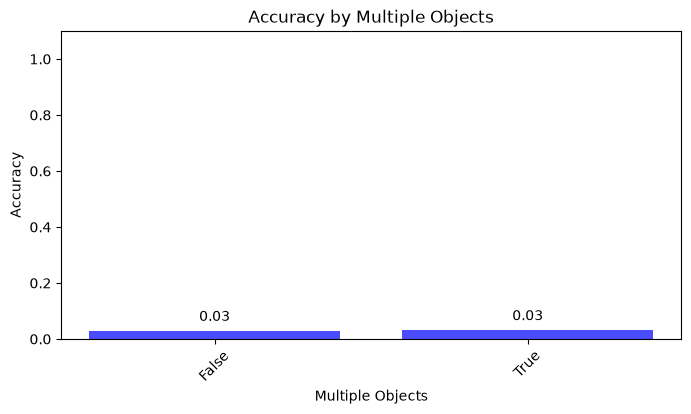

In [128]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='accuracy', title='Accuracy by Multiple Objects', ylabel='Accuracy', xlabel='Multiple Objects')


### Precision


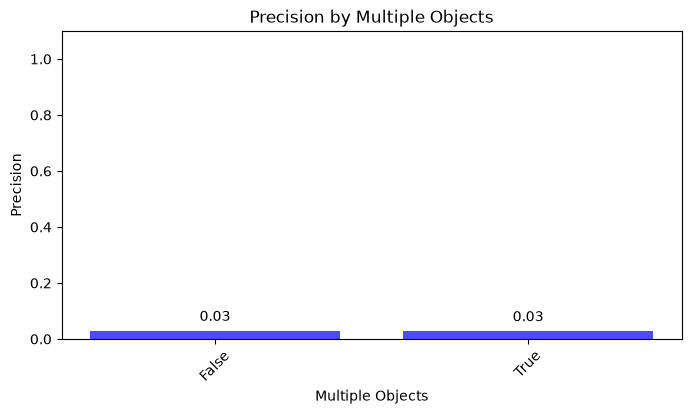

In [129]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='precision', title='Precision by Multiple Objects', ylabel='Precision', xlabel='Multiple Objects')


### Recall


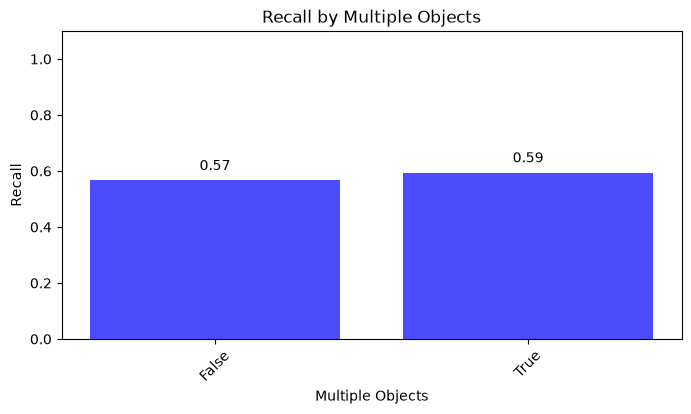

In [130]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='recall', title='Recall by Multiple Objects', ylabel='Recall', xlabel='Multiple Objects')


### Hit Rate


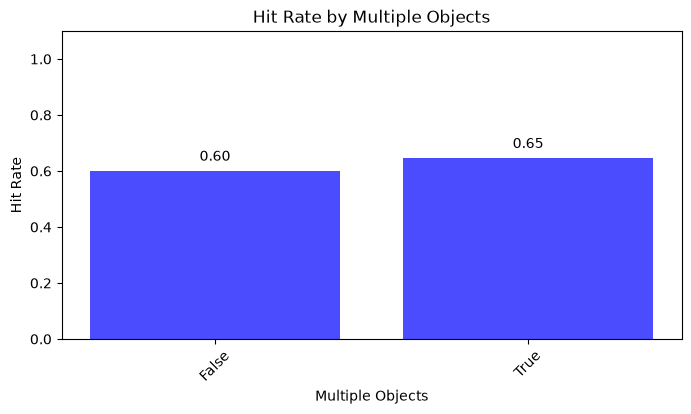

In [131]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='hit_rate', title='Hit Rate by Multiple Objects', ylabel='Hit Rate', xlabel='Multiple Objects')


### Diversity


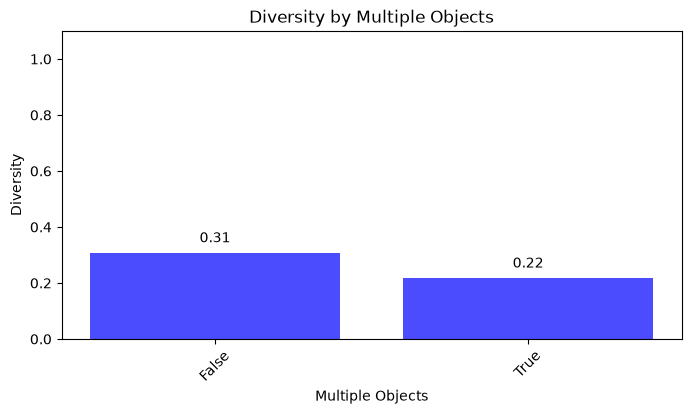

In [132]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='diversity', title='Diversity by Multiple Objects', ylabel='Diversity', xlabel='Multiple Objects')


### NDCG


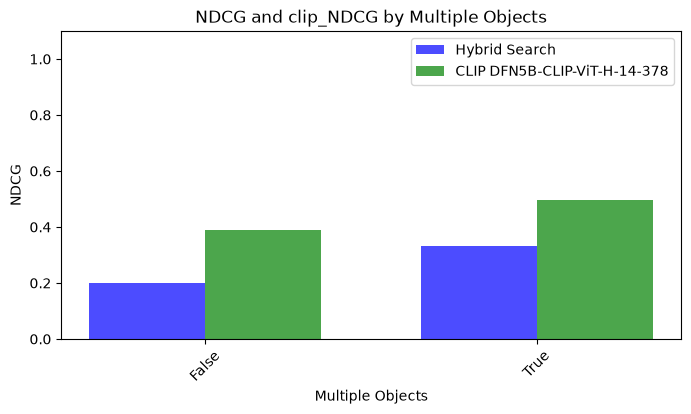

In [133]:
plot_rank_comparison(multiple_objects_metrics, x_column='multiple_objects', title='NDCG and clip_NDCG by Multiple Objects', xlabel='Multiple Objects')


### MRR


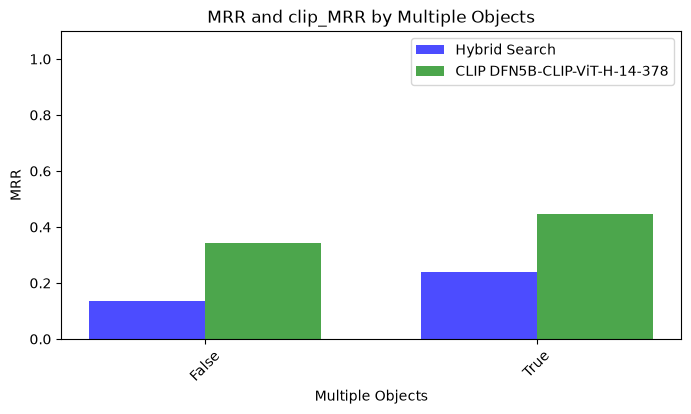

In [134]:
plot_rank_comparison(multiple_objects_metrics, x_column='multiple_objects', title='MRR and clip_MRR by Multiple Objects', xlabel='Multiple Objects', metric="MRR")


## Metrics based on Viewpoint & Precipitation Visible

Here we will group by Precipitation Visible and Viewpoint and calculate the sum/mean of each metric to see how the system performs under different Precipitation Visible and Viewpoint conditions.

>NOTE: due to the large number of combinations you can group by, we will not show all of them. Use this section as a guide if you want to break down the data by different combinations of the metadata.

In [135]:
# Group
view_preci_metrics = df.groupby(['viewpoint', 'precipitation_visible']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()
view_preci_metrics['precipitation_visible'] = view_preci_metrics['precipitation_visible'].map({True: 'True', False: 'False'})

#rename columns
view_preci_metrics = view_preci_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = view_preci_metrics
x_column = 'viewpoint'
group_column = 'precipitation_visible'
title = 'Viewpoint & Precipitation Visible'
colors = {
    "True": "green",
    "False": "red",
}

metrics

,viewpoint,precipitation_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,duo_view,False,50,2,48,2,48,0.040000,0.040000,1.000000,1.000000,0.308247,0.750000,0.118056,0.666667,0.188006
1,fisheye_sky,False,625,26,599,21,604,0.041600,0.033600,0.646667,0.760000,0.364618,0.591127,0.244146,0.533556,0.178138
2,fisheye_sky,True,75,2,73,2,73,0.026667,0.026667,0.666667,0.666667,0.248714,0.543643,0.125000,0.500000,0.169793
3,ground_horizontal,False,1900,50,1850,46,1854,0.026316,0.024211,0.561842,0.592105,0.301742,0.447742,0.214361,0.402684,0.239872
4,ground_horizontal,True,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,0.250000,0.430677,0.066667,0.250000,0.245754
5,ground_upward,False,150,5,145,5,145,0.033333,0.033333,0.833333,0.833333,0.452806,0.530309,0.358772,0.433333,0.271401
6,oblique,False,125,3,122,2,123,0.024000,0.016000,0.300000,0.400000,0.300000,0.400000,0.266667,0.400000,0.193174
7,unknown,False,50,2,48,2,48,0.040000,0.040000,0.333333,0.500000,0.377508,0.438608,0.500000,0.500000,0.357865


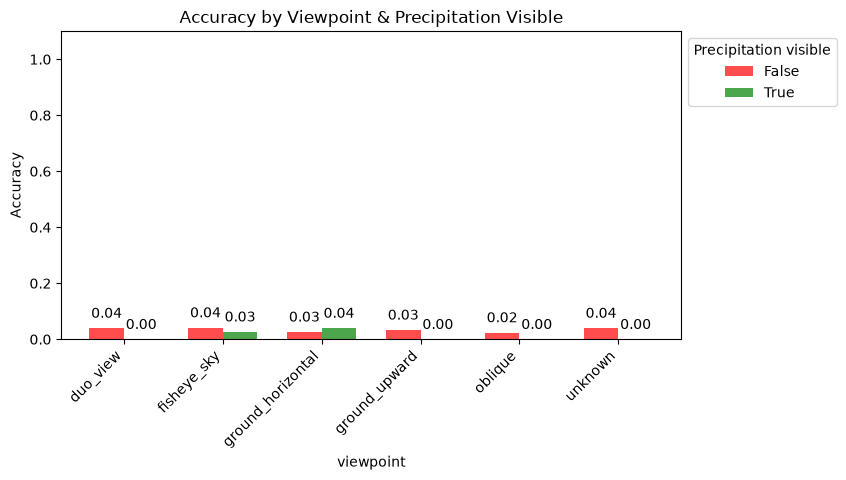

In [136]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='accuracy', 
    color_map=colors, 
    ylabel="Accuracy", 
    xlabel=x_column, 
    title=f"Accuracy by {title}",
)

### Precision

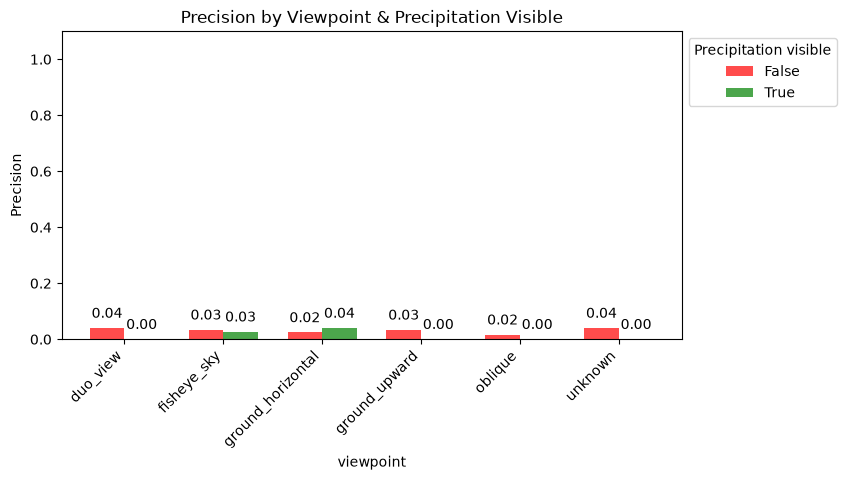

In [137]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='precision', 
    color_map=colors, 
    ylabel="Precision", 
    xlabel=x_column, 
    title=f"Precision by {title}",
)

### Recall

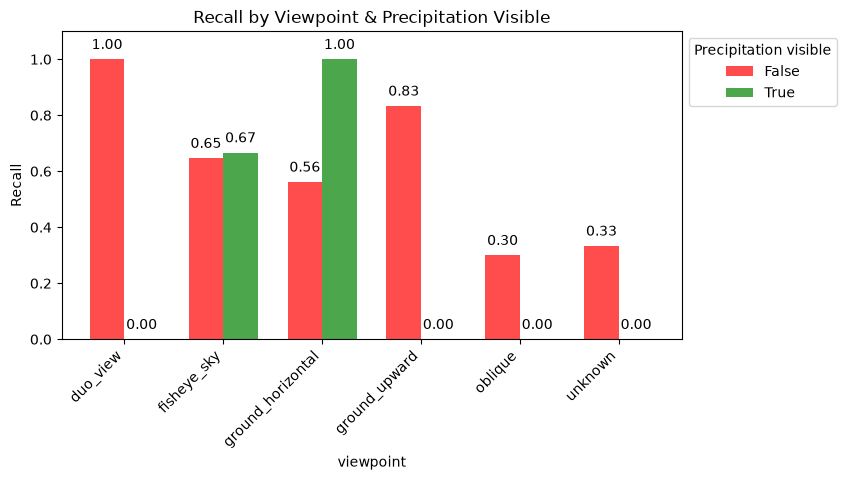

In [138]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='recall', 
    color_map=colors,
    ylabel="Recall", 
    xlabel=x_column, 
    title=f"Recall by {title}",
)


### Hit Rate

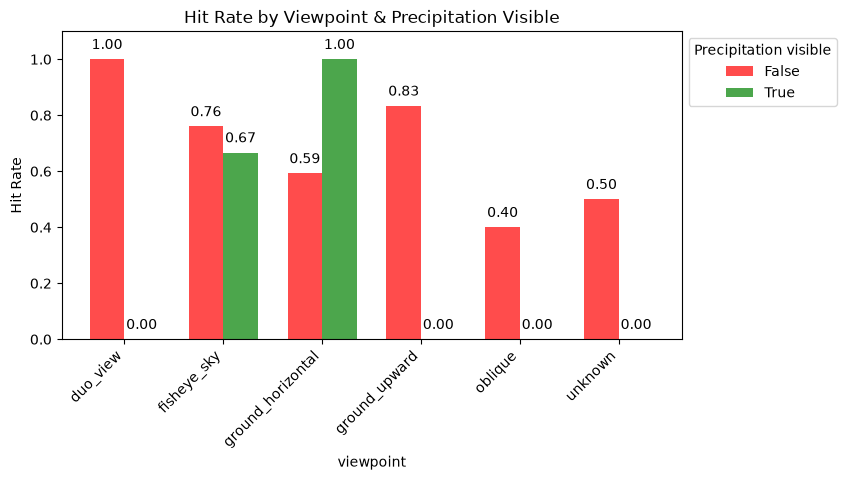

In [139]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='hit_rate', 
    color_map=colors,
    ylabel="Hit Rate", 
    xlabel=x_column, 
    title=f"Hit Rate by {title}",
)

### Diversity

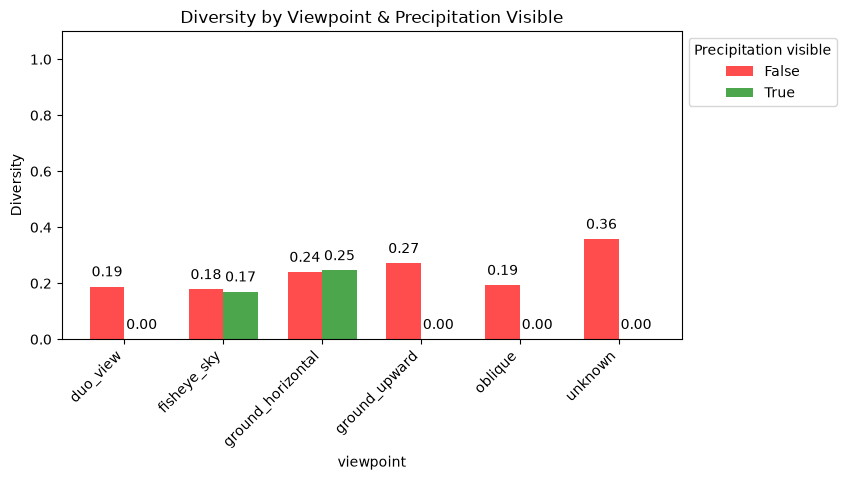

In [140]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='diversity', 
    color_map=colors,
    ylabel="Diversity", 
    xlabel=x_column, 
    title=f"Diversity by {title}",
)

### NDCG

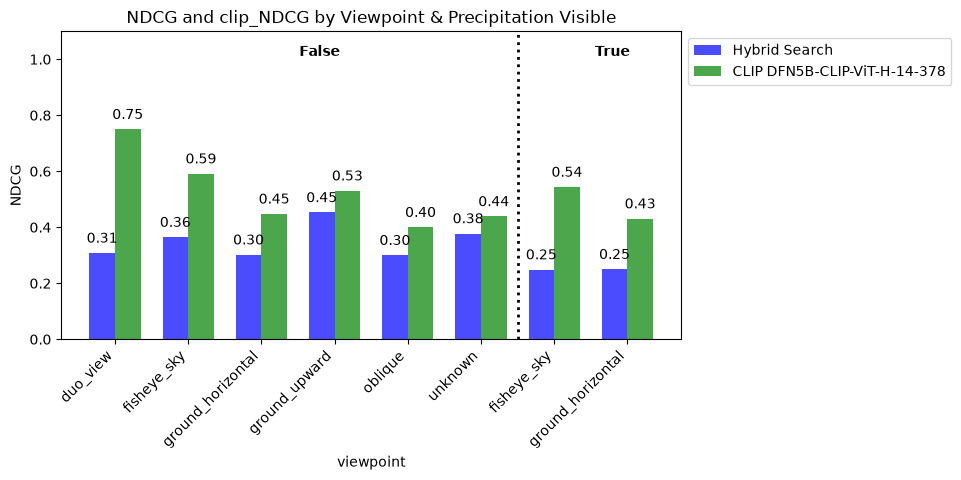

In [141]:
# Sort by group_column so group dividers and labels are correct
_ndcg_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(
    _ndcg_df,
    x_column=x_column,
    group_column=group_column,
    title=f"NDCG and clip_NDCG by {title}",
    xlabel=x_column,
)


### MRR

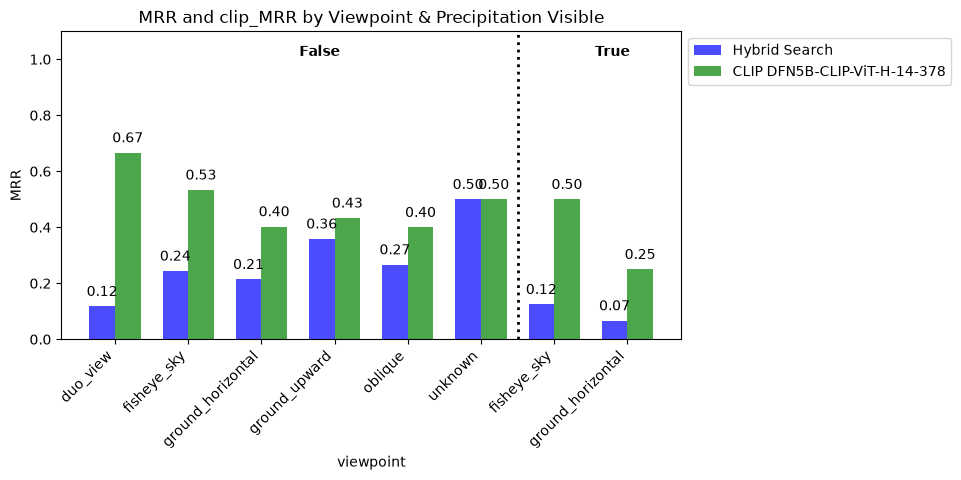

In [142]:
_mrr_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(_mrr_df, x_column=x_column, group_column=group_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Insights & Conclusion

**System Difference**

* **v12:** Weaviate hybrid search over **one fused CLIP index** (caption + image embeddings combined into a single `clip` vector), with the Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. CLIP inference had **no Triton dynamic batching**.
* **v14:**
  * introduced in v13:
    * **Weaviate → Milvus** as the vector database.
    * **Weaviate reranker → Apple CLIP DFN** (`DFN5B-CLIP-ViT-H-14-378`): query text vs stored `image_vector`s.
    * **One fused index → dual indexing**: separate `caption_vector` and `image_vector` fields, blended at query time (`clip_alpha=0.7`).
    * **No Triton batching → Triton dynamic batching** for CLIP (and Gemma when served on Triton), so concurrent embedding/caption requests coalesce into larger GPU batches.
  * v13 additions plus LLM Image Byte Limiting - Caption images are preprocessed before NRP gemma calls: RGB conversion, longest-side cap (`LLM_MAX_IMAGE_SIDE=6144`), and JPEG downscale/quality stepping to stay under `LLM_MAX_IMAGE_BYTES` (12 MiB).
* **v15:**
  * **Two-caption prompt** (`scientific_two_captions_v1`): Gemma emits `long_caption`, `short_caption` (≤55 tokens, visible content only), and 15 `keywords`.
  * **CLIP vs BM25 text split**: `caption_vector` embeds **`short_caption` + `keywords`** in one 77-token CLIP pass (keywords used to fall past the truncation cutoff). BM25 `search_text` still indexes **`long_caption` + keywords**.
  * **Schema**: `long_caption` and `short_caption` stored as separate VARCHAR fields (replacing a single `caption` column).
  * Hybrid weights unchanged (`query_alpha=0.4`, `clip_alpha=0.7`). CLIP DFN still reranks on `image_vector`.

---

**Overall Metrics Comparison**

v15 is the short-caption CLIP split on the v14 stack. **Δ (v14 − v12)** is the Milvus / dual-index / CLIP DFN / byte-limiting net vs Weaviate; **Δ (v15 − v14)** is the caption-text split; **Δ (v15 − v12)** is the net vs the Weaviate baseline.

| Metric                   | v12 | v14 | v15 | Δ (v14 − v12) | Δ (v15 − v14) | Δ (v15 − v12) |
| ------------------------ | --- | --- | --- | ------------- | ------------- | ------------- |
| **Total Images**         | 3,000 | 3,000 | 3,000 | 0 | 0 | 0 |
| **Correctly Returned**   | 79 | 96 | 91 | +17 | −5 | +12 |
| **Incorrectly Returned** | 2,921 | 2,904 | 2,909 | −17 | +5 | −12 |
| **Relevant Images**      | 68 | 85 | 81 | +17 | −4 | +13 |
| **Accuracy**             | 0.0263 | 0.0320 | 0.0303 | +0.0057 | −0.0017 | +0.0040 |
| **Precision**            | 0.0227 | 0.0283 | 0.0270 | +0.0056 | −0.0013 | +0.0043 |
| **Recall**               | 0.5033 | 0.6146 | 0.5919 | +0.1113 | −0.0227 | +0.0886 |
| **Hit Rate**             | 0.5417 | 0.6667 | 0.6417 | +0.1250 | −0.0250 | +0.1000 |
| **Diversity**            | 0.2070 | 0.2287 | 0.2260 | +0.0217 | −0.0027 | +0.0190 |
| **NDCG** | 0.2111 | 0.2949 | 0.3219 | +0.0838 | +0.0271 | +0.1108 |
| **clip_NDCG** | 0.4274 | 0.4672 | 0.4869 | +0.0398 | +0.0197 | +0.0595 |
| **MRR** | 0.1218 | 0.1931 | 0.2297 | +0.0713 | +0.0365 | +0.1079 |
| **clip_MRR** | 0.3915 | 0.4050 | 0.4386 | +0.0135 | +0.0335 | +0.0471 |
| **DLQ entries**          | — | 0 | 0 | — | 0 | — |

---

**Interpretation**

**The ingest split is working as designed — and on Sagebench it moves ranking, not coverage.** v15 embeds visual-only `short_caption` + keywords (no device IDs or timestamps). BM25 still has `long_caption` plus Sage metadata in `search_text`. Hybrid weights and CLIP `image_vector` rerank are unchanged. DLQ stays **0**.

**Labeled coverage eases slightly vs v14, still well above v12.** Hit rate **66.7% → 64.2%** (80/120 → 77/120). **Relevant images** −4, **recall** −0.023. Versus v12 this is still a **+10 pp** hit-rate win (54.2% → 64.2%).

**Production first-hit ranking is the v15 win.** **MRR 0.19 → 0.23** (v12 0.12) and **NDCG 0.29 → 0.32**. **clip_NDCG / clip_MRR** tick up. The gap to the CLIP oracle stays large (**MRR 0.23 vs clip_MRR 0.44**): short visual captions help CLIP put the right *look* earlier, but they cannot prefer a specific VSN. That is the Sage metadata hole, not a caption-truncation hole.

**Diversity** is unchanged.

---

**Insights**

- **Isolate v15 vs v14.** Same Milvus dual-index, same `clip_alpha=0.7` / `query_alpha=0.4`, same CLIP DFN rerank, same byte limiting. The only IR change is *what* is CLIP-embedded as `caption_vector`.
- **Stripping device IDs from CLIP is the point — and it costs a little coverage.** v14's truncated `caption_vector` was mostly boilerplate (node IDs, timestamps) shared across thousands of frames, which could accidentally match “from vsn V041” in the query. v15's short caption is visual-only by prompt. Hit rate dips; **MRR rises**. BM25 still carries vsn/zone/job in `search_text`; CLIP rerank still ignores them.
- **Fisheye / sky keep climbing; vegetation and night give some back.** Fisheye hit **0.64 → 0.75**; sky-dominant **0.60 → 0.74**; top_camera **0.56 → 0.67**. Vegetation **0.70 → 0.40**; night **0.71 → 0.61**; ground-horizontal **0.68 → 0.60**. Short “fisheye sky, pole, sun” sentences are CLIP-friendly; night IR / forest / same-looking nodes still need metadata to disambiguate.
- **Hit churn nets −3:** 14 gained, 17 lost. Gains include V041 tower platforms, mobotix RGB/thermal, and shield/APIARY fisheye. Losses mix night forests, some V041 duplicates, and vegetation/glare ground views.
- **The remaining ranking hole is still metadata vs CLIP rerank**, not 77-token truncation. Isolate this increment with **v15 vs v14**. Do not read v15 vs v12 as “short captions vs Weaviate.” Next Sage IR work is still **VSN/zone filter or boost**, then **`clip_alpha`**, not rolling back the two-caption prompt.

---

**Conclusion**

On Sagebench, **v15 is the right ingest default on top of v14:** DLQ stays 0, coverage stays far above v12, and **MRR / NDCG jump** (0.19 → 0.23 / 0.29 → 0.32). Hit rate dips **2.5 pp**. Keep the two-caption prompt. Next work is still **structured Sage fields at query time** so first-hit ranking can use node identity, plus the **`clip_alpha` / `query_alpha` sweep** on this honest `caption_vector` — not rolling back Milvus, CLIP DFN, or the short-caption split.
